In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import random
import math

In [2]:
df = pd.read_excel('Новый диплом датасет update.xlsx', sheet_name=None) # Загрузка ексель файлов
# df — это словарь. Смотрим его ключи (названия вкладок)
print(df.keys())
df_data =df['Данные']
df_clients =df['Clients']
df_region_dict =df['Region_dict']

dict_keys(['Данные', 'Clients', 'Region_dict'])


In [3]:
df_data.head()

,id_order,id_client,amt_payment,dtime_pay
0,100238,194569.0,5373.0,2022-07-17 21:48:15.896
1,100242,191056.0,4151.0,2022-07-07 03:09:39.699
2,100249,200049.0,5688.0,2022-07-29 13:25:59.976
3,100258,206161.0,4330.0,2022-08-15 22:55:02.538
4,100267,190945.0,5488.0,2022-07-05 19:46:47.174


<div style="
    background: linear-gradient(145deg, #f3e7ff, #ffffff);
    padding: 60px 40px 50px 40px;
    border-radius: 26px;
    box-shadow: 0 12px 28px rgba(128, 0, 128, 0.18);
    border: 2px solid #C850C0;
    margin: 8px 0;
">

<h2 style="
    background: linear-gradient(90deg, #C850C0, #A844B0, #7B2FBE);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    text-align: center;
    font-size: 28px;
    margin: 0 0 12px 0;
    font-weight: bold;
">🛒 A/B-тест: Пуш-уведомления vs Баннеры</h2>

<h4 style="text-align: center; color: #4a2f5e; margin: 0 0 20px 0; font-weight: normal;">
  SkyLenta &nbsp;|&nbsp; Продуктовая аналитика
</h4>

<h3 style="color: #7B2FBE; font-size: 20px; margin: 24px 0 12px 0;">📋 Контекст</h3>

<table style="width: 100%; font-size: 16px; border-collapse: collapse; background: #F9F6FC; border-radius: 14px; overflow: hidden;">
  <tr>
    <th style="background: #7B2FBE; color: white; padding: 14px; text-align: center;">Параметр</th>
    <th style="background: #7B2FBE; color: white; padding: 14px; text-align: center;">Описание</th>
  </tr>
  <tr style="background: #f3ebf7;">
    <td style="padding: 14px; text-align: center; color: #2C3E50;"><strong>Компания</strong></td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">SkyLenta — крупный ретейлер, присутствует во многих городах России</td>
  </tr>
  <tr style="background: #e6d9ed;">
    <td style="padding: 14px; text-align: center; color: #2C3E50;"><strong>Проблема</strong></td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">Маркетинг использовал баннеры. Отдел предложил перейти на пуш-уведомления, считая их эффективнее</td>
  </tr>
  <tr style="background: #f3ebf7;">
    <td style="padding: 14px; text-align: center; color: #2C3E50;"><strong>Цель</strong></td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">Сравнить два формата и понять, какой даёт лучшую конверсию и средний чек</td>
  </tr>
</table>

<h3 style="color: #7B2FBE; font-size: 20px; margin: 24px 0 12px 0;">🧪 Дизайн эксперимента</h3>

<table style="width: 100%; font-size: 16px; border-collapse: collapse; background: #F9F6FC; border-radius: 14px; overflow: hidden;">
  <tr>
    <th style="background: #7B2FBE; color: white; padding: 14px; text-align: center;">Параметр</th>
    <th style="background: #7B2FBE; color: white; padding: 14px; text-align: center;">Значение</th>
  </tr>
  <tr style="background: #f3ebf7;">
    <td style="padding: 14px; text-align: center; color: #2C3E50;">Длительность</td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">3 месяца</td>
  </tr>
  <tr style="background: #e6d9ed;">
    <td style="padding: 14px; text-align: center; color: #2C3E50;">География</td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">Все города присутствия ретейлера</td>
  </tr>
  <tr style="background: #f3ebf7;">
    <td style="padding: 14px; text-align: center; color: #2C3E50;">Сплитование</td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">Случайное, две равные группы</td>
  </tr>
  <tr style="background: #e6d9ed;">
    <td style="padding: 14px; text-align: center; color: #2C3E50;">Контроль</td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">Баннеры (старый формат)</td>
  </tr>
  <tr style="background: #f3ebf7;">
    <td style="padding: 14px; text-align: center; color: #2C3E50;">Тест</td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">Пуш-уведомления (новый формат)</td>
  </tr>
  <tr style="background: #e6d9ed;">
    <td style="padding: 14px; text-align: center; color: #2C3E50;">Метрики</td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">Конверсия в покупку, Средний чек (ARPU)</td>
  </tr>
</table>

</div>

In [4]:
df_clients.head()

,id_client,dtime_ad,nflag_test,id_trading_point
0,180844,2022-06-08 18:38:41.414,0,212
1,193942,NaT,0,13
2,226069,2022-07-11 16:28:38.511,1,54
3,183981,2022-06-16 12:23:59.289,1,991
4,322530,2022-07-08 08:56:08.714,0,1015


In [5]:
df_region_dict.head()

,id_trading_point,city
0,1,Петрозаводск
1,2,Дмитров
2,4,Чехов
3,7,Ростов Великий
4,11,Владимир


In [6]:
payments_sum = df_data.groupby('id_client')['amt_payment'].sum().reset_index()
payments_sum.columns = ['id_client', 'amt_payment']
payments_sum.head()

,id_client,amt_payment
0,178561.0,3052.0
1,178562.0,2439.0
2,178563.0,768.0
3,178564.0,0.0
4,178565.0,958.0


In [7]:
df_merged = df_clients.merge(payments_sum, on='id_client', how='left')
df_merged['amt_payment'] = df_merged['amt_payment'].fillna(0)
df_merged.head()

,id_client,dtime_ad,nflag_test,id_trading_point,amt_payment
0,180844,2022-06-08 18:38:41.414,0,212,5349.0
1,193942,NaT,0,13,4144.0
2,226069,2022-07-11 16:28:38.511,1,54,0.0
3,183981,2022-06-16 12:23:59.289,1,991,6322.0
4,322530,2022-07-08 08:56:08.714,0,1015,0.0


In [8]:
df = df_merged.merge(df_region_dict, on='id_trading_point', how='left')

<div style="
    background: linear-gradient(145deg, #f3e7ff, #ffffff);
    padding: 60px 40px 50px 40px;
    border-radius: 26px;
    box-shadow: 0 12px 28px rgba(128, 0, 128, 0.18);
    border: 2px solid #C850C0;
    margin: 8px 0;
">

<h2 style="
    background: linear-gradient(90deg, #C850C0, #A844B0, #7B2FBE);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    text-align: center;
    font-size: 28px;
    margin: 0 0 12px 0;
    font-weight: bold;
">📋 Описание данных для A/B-теста</h2>

<h4 style="text-align: center; color: #4a2f5e; margin: 0 0 20px 0; font-weight: normal;">
  Файл: Новый диплом датасет update.xlsx
</h4>

<h3 style="color: #7B2FBE; font-size: 20px; margin: 24px 0 12px 0;">📊 Вкладка «Данные» (платежи)</h3>

<table style="width: 100%; font-size: 16px; border-collapse: collapse; background: #F9F6FC; border-radius: 14px; overflow: hidden;">
  <tr>
    <th style="background: #7B2FBE; color: white; padding: 14px; text-align: center;">Столбец</th>
    <th style="background: #7B2FBE; color: white; padding: 14px; text-align: center;">Тип</th>
    <th style="background: #7B2FBE; color: white; padding: 14px; text-align: center;">Описание</th>
  </tr>
  <tr style="background: #f3ebf7;">
    <td style="padding: 14px; text-align: center;">id_order</td>
    <td style="padding: 14px; text-align: center;">int</td>
    <td style="padding: 14px; text-align: center;">Уникальный идентификатор покупки</td>
  </tr>
  <tr style="background: #e6d9ed;">
    <td style="padding: 14px; text-align: center;">id_client</td>
    <td style="padding: 14px; text-align: center;">int</td>
    <td style="padding: 14px; text-align: center;">Уникальный идентификатор клиента</td>
  </tr>
  <tr style="background: #f3ebf7;">
    <td style="padding: 14px; text-align: center;">amt_payment</td>
    <td style="padding: 14px; text-align: center;">float</td>
    <td style="padding: 14px; text-align: center;">Размер платежа (сумма покупки)</td>
  </tr>
  <tr style="background: #e6d9ed;">
    <td style="padding: 14px; text-align: center;">dtime_pay</td>
    <td style="padding: 14px; text-align: center;">datetime</td>
    <td style="padding: 14px; text-align: center;">Дата и время оплаты</td>
  </tr>
</table>

<div style="background: #e6d9ed; padding: 16px; margin-top: 20px; border-radius: 12px; text-align: center; font-size: 15px; color: #2C3E50;">
  📌 <strong>Роль в тесте:</strong> целевая метрика (amt_payment) и временна́я привязка покупки.
</div>

<h3 style="color: #7B2FBE; font-size: 20px; margin: 24px 0 12px 0;">👥 Вкладка «Clients» (участники эксперимента)</h3>

<table style="width: 100%; font-size: 16px; border-collapse: collapse; background: #F9F6FC; border-radius: 14px; overflow: hidden;">
  <tr>
    <th style="background: #7B2FBE; color: white; padding: 14px; text-align: center;">Столбец</th>
    <th style="background: #7B2FBE; color: white; padding: 14px; text-align: center;">Тип</th>
    <th style="background: #7B2FBE; color: white; padding: 14px; text-align: center;">Описание</th>
  </tr>
  <tr style="background: #f3ebf7;">
    <td style="padding: 14px; text-align: center;">id_client</td>
    <td style="padding: 14px; text-align: center;">int</td>
    <td style="padding: 14px; text-align: center;">Уникальный идентификатор клиента</td>
  </tr>
  <tr style="background: #e6d9ed;">
    <td style="padding: 14px; text-align: center;">dtime_ad</td>
    <td style="padding: 14px; text-align: center;">datetime</td>
    <td style="padding: 14px; text-align: center;">Дата и время показа рекламного объявления</td>
  </tr>
  <tr style="background: #f3ebf7;">
    <td style="padding: 14px; text-align: center;">nflag_test</td>
    <td style="padding: 14px; text-align: center;">int</td>
    <td style="padding: 14px; text-align: center;"><strong>Группа эксперимента:</strong> 0 — контроль, 1 — тест</td>
  </tr>
  <tr style="background: #e6d9ed;">
    <td style="padding: 14px; text-align: center;">id_trading_point</td>
    <td style="padding: 14px; text-align: center;">int</td>
    <td style="padding: 14px; text-align: center;">Идентификатор торговой точки</td>
  </tr>
</table>

<div style="background: #e6d9ed; padding: 16px; margin-top: 20px; border-radius: 12px; text-align: center; font-size: 15px; color: #2C3E50;">
  📌 <strong>Роль в тесте:</strong> флаг разбиения на группы (nflag_test) и географическая привязка (id_trading_point).
</div>

<h3 style="color: #7B2FBE; font-size: 20px; margin: 24px 0 12px 0;">🏙️ Вкладка «Region_dict» (справочник городов)</h3>

<table style="width: 100%; font-size: 16px; border-collapse: collapse; background: #F9F6FC; border-radius: 14px; overflow: hidden;">
  <tr>
    <th style="background: #7B2FBE; color: white; padding: 14px; text-align: center;">Столбец</th>
    <th style="background: #7B2FBE; color: white; padding: 14px; text-align: center;">Тип</th>
    <th style="background: #7B2FBE; color: white; padding: 14px; text-align: center;">Описание</th>
  </tr>
  <tr style="background: #f3ebf7;">
    <td style="padding: 14px; text-align: center;">id_trading_point</td>
    <td style="padding: 14px; text-align: center;">int</td>
    <td style="padding: 14px; text-align: center;">Уникальный идентификатор торговой точки</td>
  </tr>
  <tr style="background: #e6d9ed;">
    <td style="padding: 14px; text-align: center;">city</td>
    <td style="padding: 14px; text-align: center;">str</td>
    <td style="padding: 14px; text-align: center;">Название города</td>
  </tr>
</table>

<div style="background: #e6d9ed; padding: 16px; margin-top: 20px; border-radius: 12px; text-align: center; font-size: 15px; color: #2C3E50;">
  📌 <strong>Роль в тесте:</strong> расшифровка географии для сегментного анализа.
</div>

<h3 style="color: #7B2FBE; font-size: 20px; margin: 24px 0 12px 0;">🔗 Связи между таблицами</h3>

<div style="background: #e6d9ed; padding: 16px; margin-top: 20px; border-radius: 12px; text-align: center; font-size: 15px; color: #2C3E50;">
  Данные.id_client ←→ Clients.id_client &nbsp;&nbsp;|&nbsp;&nbsp; Clients.id_trading_point ←→ Region_dict.id_trading_point
</div>

</div>

In [9]:
df.head()

,id_client,dtime_ad,nflag_test,id_trading_point,amt_payment,city
0,180844,2022-06-08 18:38:41.414,0,212,5349.0,Красноярск
1,193942,NaT,0,13,4144.0,Нижний Новгород
2,226069,2022-07-11 16:28:38.511,1,54,0.0,Мурманск
3,183981,2022-06-16 12:23:59.289,1,991,6322.0,Казань
4,322530,2022-07-08 08:56:08.714,0,1015,0.0,Краснодар


In [10]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55605 entries, 0 to 55604
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id_client         55605 non-null  int64         
 1   dtime_ad          55356 non-null  datetime64[ns]
 2   nflag_test        55605 non-null  int64         
 3   id_trading_point  55605 non-null  int64         
 4   amt_payment       55605 non-null  float64       
 5   city              55605 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 2.5+ MB


In [11]:
df.isnull().sum()          # количество пропусков в каждой колонке

id_client             0
dtime_ad            249
nflag_test            0
id_trading_point      0
amt_payment           0
city                  0
dtype: int64

In [12]:
df.count()

id_client           55605
dtime_ad            55356
nflag_test          55605
id_trading_point    55605
amt_payment         55605
city                55605
dtype: int64

In [13]:
def full_check(df):
    print('=== РАЗМЕР ===')
    print(f'Строк: {df.shape[0]}, Колонок: {df.shape[1]}')
    
    print('\n=== ПРОПУСКИ ===')
    print(df.isnull().sum())
    
    print('\n=== БЕСКОНЕЧНОСТИ ===')
    print(df.isin([np.inf, -np.inf]).sum())
    
    print('\n=== ТИПЫ ===')
    print(df.dtypes)
    
    print('\n=== ДУБЛИКАТЫ ===')
    print(f'Дубликатов: {df.duplicated().sum()}')
    
    print('\n=== СТАТИСТИКА ===')
    print(df.describe())
    
    # Проверка текста в числовых колонках
    for col in df.select_dtypes(include=['object']).columns:
        non_num = df[~df[col].astype(str).str.isdigit()]
        if len(non_num) > 0:
            print(f'\n⚠️ В колонке {col} есть текст: {non_num[col].unique()[:5]}')
    
    print('\n=== УНИКАЛЬНЫЕ ЗНАЧЕНИЯ ===')
    for col in df.columns:
        print(f'{col}: {df[col].nunique()} уникальных')

In [14]:
full_check(df)

=== РАЗМЕР ===
Строк: 55605, Колонок: 6

=== ПРОПУСКИ ===
id_client             0
dtime_ad            249
nflag_test            0
id_trading_point      0
amt_payment           0
city                  0
dtype: int64

=== БЕСКОНЕЧНОСТИ ===
id_client           0
dtime_ad            0
nflag_test          0
id_trading_point    0
amt_payment         0
city                0
dtype: int64

=== ТИПЫ ===
id_client                    int64
dtime_ad            datetime64[ns]
nflag_test                   int64
id_trading_point             int64
amt_payment                float64
city                        object
dtype: object

=== ДУБЛИКАТЫ ===
Дубликатов: 0

=== СТАТИСТИКА ===
           id_client                       dtime_ad    nflag_test  \
count   55605.000000                          55356  55605.000000   
mean   227974.818344  2022-07-15 01:22:51.286130176      0.463879   
min    178561.000000     2022-06-03 02:47:49.183000      0.000000   
25%    192462.000000  2022-06-24 23:53:54.80425011

In [15]:
df = df.dropna(subset=['nflag_test'])# Перезаписали ДФ и исключили из него нулы в дате 
df.head() # Метод пандас который исключает нулы в ДФ и subset который явно указывает в каких колонках их исключить 

,id_client,dtime_ad,nflag_test,id_trading_point,amt_payment,city
0,180844,2022-06-08 18:38:41.414,0,212,5349.0,Красноярск
1,193942,NaT,0,13,4144.0,Нижний Новгород
2,226069,2022-07-11 16:28:38.511,1,54,0.0,Мурманск
3,183981,2022-06-16 12:23:59.289,1,991,6322.0,Казань
4,322530,2022-07-08 08:56:08.714,0,1015,0.0,Краснодар


In [16]:
#  присвоить результат в столбец
df['amt_payment'] = df['amt_payment'].fillna(0)

In [17]:
df = df.copy()

# Сначала заполняем NaN в id_order и id_client, потом приводим к int
#df['id_order'] = df['id_order'].fillna(-1).astype(int)
df['id_client'] = df['id_client'].fillna(-1).astype(int)

# Эти столбцы уже без NaN — можно сразу в int
df['amt_payment'] = df['amt_payment'].astype(int)
df['nflag_test'] = df['nflag_test'].astype(int)
df['id_trading_point'] = df['id_trading_point'].astype(int)

print(df.dtypes)
df.head()

id_client                    int64
dtime_ad            datetime64[ns]
nflag_test                   int64
id_trading_point             int64
amt_payment                  int64
city                        object
dtype: object


,id_client,dtime_ad,nflag_test,id_trading_point,amt_payment,city
0,180844,2022-06-08 18:38:41.414,0,212,5349,Красноярск
1,193942,NaT,0,13,4144,Нижний Новгород
2,226069,2022-07-11 16:28:38.511,1,54,0,Мурманск
3,183981,2022-06-16 12:23:59.289,1,991,6322,Казань
4,322530,2022-07-08 08:56:08.714,0,1015,0,Краснодар


In [18]:
full_check(df)

=== РАЗМЕР ===
Строк: 55605, Колонок: 6

=== ПРОПУСКИ ===
id_client             0
dtime_ad            249
nflag_test            0
id_trading_point      0
amt_payment           0
city                  0
dtype: int64

=== БЕСКОНЕЧНОСТИ ===
id_client           0
dtime_ad            0
nflag_test          0
id_trading_point    0
amt_payment         0
city                0
dtype: int64

=== ТИПЫ ===
id_client                    int64
dtime_ad            datetime64[ns]
nflag_test                   int64
id_trading_point             int64
amt_payment                  int64
city                        object
dtype: object

=== ДУБЛИКАТЫ ===
Дубликатов: 0

=== СТАТИСТИКА ===
           id_client                       dtime_ad    nflag_test  \
count   55605.000000                          55356  55605.000000   
mean   227974.818344  2022-07-15 01:22:51.286130176      0.463879   
min    178561.000000     2022-06-03 02:47:49.183000      0.000000   
25%    192462.000000  2022-06-24 23:53:54.80425011

<Axes: ylabel='amt_payment'>

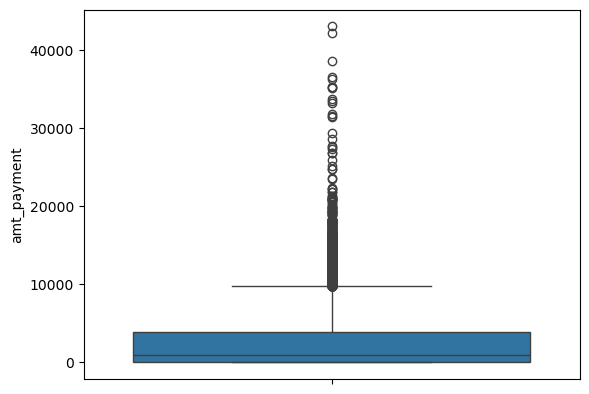

In [19]:
# === Ящик с усами ===      Построили график что бы посмотреть выбросы (библиотека seaborn)
sns.boxplot(df['amt_payment'])

In [20]:
(df['amt_payment']>7000).sum()

np.int64(3417)

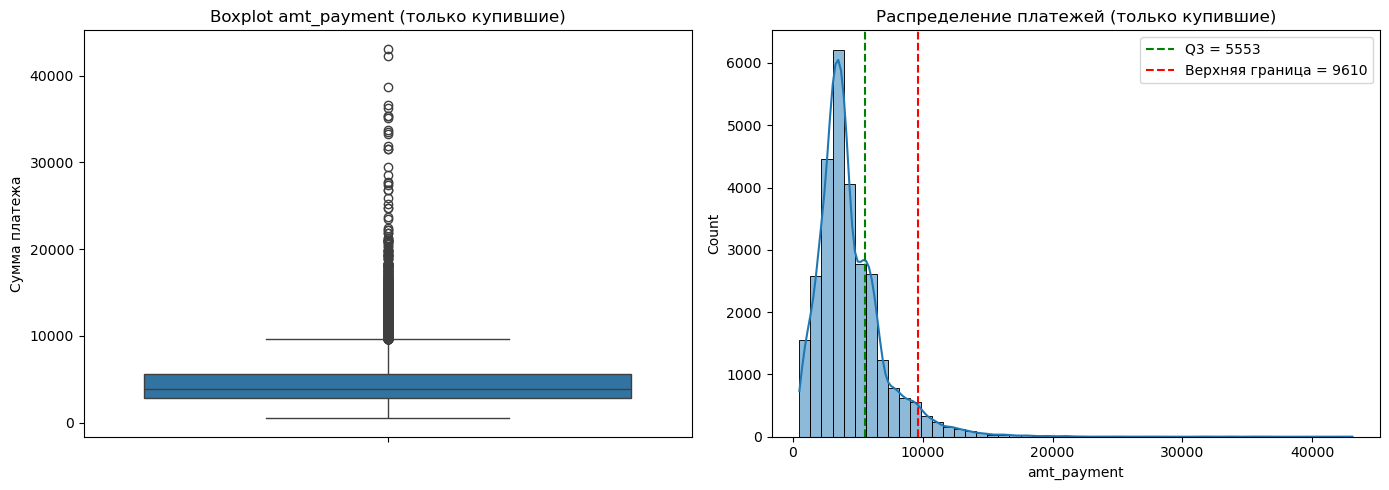

In [21]:
# Только те, у кого был платёж
df_payers = df[df['amt_payment'] > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(y=df_payers['amt_payment'], ax=axes[0])
axes[0].set_title('Boxplot amt_payment (только купившие)')
axes[0].set_ylabel('Сумма платежа')

sns.histplot(df_payers['amt_payment'], bins=50, kde=True, ax=axes[1])
Q1 = df_payers['amt_payment'].quantile(0.25)
Q3 = df_payers['amt_payment'].quantile(0.75)
upper_bound = Q3 + 1.5 * (Q3 - Q1)
axes[1].axvline(Q3, color='green', linestyle='--', label=f'Q3 = {Q3:.0f}')
axes[1].axvline(upper_bound, color='red', linestyle='--', label=f'Верхняя граница = {upper_bound:.0f}')
axes[1].legend()
axes[1].set_title('Распределение платежей (только купившие)')

plt.tight_layout()
plt.show()

<div style="
    background: linear-gradient(145deg, #f3e7ff, #ffffff);
    padding: 60px 40px 50px 40px;
    border-radius: 26px;
    box-shadow: 0 12px 28px rgba(128, 0, 128, 0.18);
    border: 2px solid #C850C0;
    margin: 8px 0;
">

<h2 style="
    background: linear-gradient(90deg, #C850C0, #A844B0, #7B2FBE);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    text-align: center;
    font-size: 28px;
    margin: 0 0 12px 0;
    font-weight: bold;
">🧹 Очистка данных перед A/B-тестом</h2>

<h4 style="text-align: center; color: #4a2f5e; margin: 0 0 20px 0; font-weight: normal;">
  После агрегации платежей и left join &nbsp;|&nbsp; 55 605 клиентов &nbsp;|&nbsp; 0 дубликатов
</h4>

<table style="width: 100%; font-size: 16px; border-collapse: collapse; background: #F9F6FC; border-radius: 14px; overflow: hidden;">
  <tr>
    <th style="background: #7B2FBE; color: white; padding: 14px; text-align: center;">Столбец</th>
    <th style="background: #7B2FBE; color: white; padding: 14px; text-align: center;">Пропусков</th>
    <th style="background: #7B2FBE; color: white; padding: 14px; text-align: center;">Действие</th>
    <th style="background: #7B2FBE; color: white; padding: 14px; text-align: center;">Обоснование</th>
  </tr>
  <tr style="background: #f3ebf7;">
    <td style="padding: 14px; text-align: center; color: #2C3E50;">id_client</td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">0</td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">✅</td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">Ключ — без пропусков</td>
  </tr>
  <tr style="background: #e6d9ed;">
    <td style="padding: 14px; text-align: center; color: #2C3E50;">nflag_test</td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">0</td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">✅</td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">Флаг группы — критический столбец</td>
  </tr>
  <tr style="background: #f3ebf7;">
    <td style="padding: 14px; text-align: center; color: #2C3E50;">amt_payment</td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">0</td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">✅ Заполнен нулями</td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">Некупившие получили 0 при left join → fillna(0)</td>
  </tr>
  <tr style="background: #e6d9ed;">
    <td style="padding: 14px; text-align: center; color: #2C3E50;">id_trading_point</td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">0</td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">✅</td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">Все клиенты привязаны к точке</td>
  </tr>
  <tr style="background: #f3ebf7;">
    <td style="padding: 14px; text-align: center; color: #2C3E50;">city</td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">0</td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">✅</td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">Все точки привязаны к городу</td>
  </tr>
  <tr style="background: #e6d9ed;">
    <td style="padding: 14px; text-align: center; color: #2C3E50;">dtime_ad</td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">249</td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">⚠️ Оставлены</td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">Дата показа рекламы. Не влияет на метрики теста</td>
  </tr>
</table>

<div style="background: #e6d9ed; padding: 16px; margin-top: 20px; border-radius: 12px; font-size: 15px; color: #2C3E50;">
  💡 <strong>Почему нет пропусков в amt_payment:</strong> сначала сгруппировали платежи по id_client (sum), затем left join от Clients → некупившие получили NaN → fillna(0). Каждый клиент — одна строка.
</div>

<div style="background: #f3ebf7; padding: 16px; margin-top: 16px; border-radius: 12px; font-size: 15px; color: #2C3E50;">
  💡 <strong>Почему max = 43 083 руб.:</strong> это сумма всех платежей одного клиента, а не один платёж. У одного клиента может быть несколько покупок — мы их просуммировали.
</div>

<div style="background: #e6d9ed; padding: 16px; margin-top: 16px; border-radius: 12px; font-size: 15px; color: #2C3E50;">
  ✅ <strong>Итог:</strong> 55 605 клиентов, 0 дубликатов, 0 критических пропусков. Данные готовы к A/B-тесту.
</div>

</div>

In [22]:
df.head()

,id_client,dtime_ad,nflag_test,id_trading_point,amt_payment,city
0,180844,2022-06-08 18:38:41.414,0,212,5349,Красноярск
1,193942,NaT,0,13,4144,Нижний Новгород
2,226069,2022-07-11 16:28:38.511,1,54,0,Мурманск
3,183981,2022-06-16 12:23:59.289,1,991,6322,Казань
4,322530,2022-07-08 08:56:08.714,0,1015,0,Краснодар


In [23]:
cnt_tt_city = df.groupby('city').agg(cnt_tt = ('id_trading_point', 'nunique')).reset_index()
cnt_tt_city.sort_values('cnt_tt',ascending=False).head(10)

,city,cnt_tt
15,Санкт-Петербург,11
7,Москва,11
4,Казань,6
10,Новосибирск,6
6,Красноярск,5
5,Краснодар,4
14,Самара,4
8,Мурманск,2
18,Сочи,2
16,Саратов,2


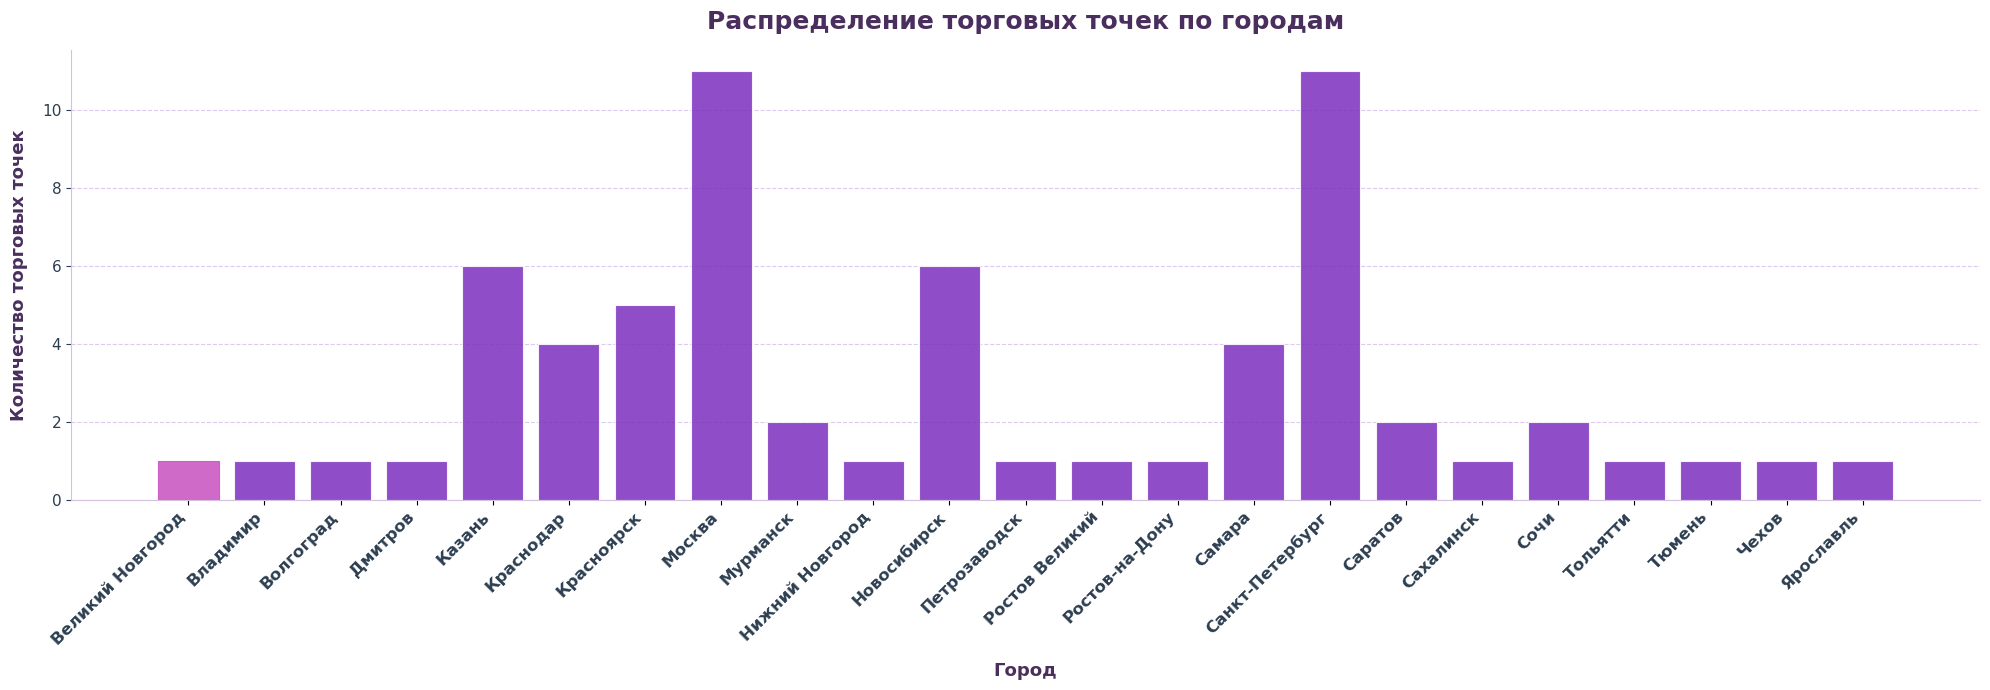

In [24]:
fig, ax = plt.subplots(figsize=(20, 7))

bars = ax.bar(cnt_tt_city['city'], cnt_tt_city['cnt_tt'], 
              color='#7B2FBE', edgecolor='white', linewidth=0.8, alpha=0.85)

bars[0].set_color('#C850C0')

ax.set_title('Распределение торговых точек по городам', 
             fontsize=18, fontweight='bold', color='#4a2f5e', pad=15)
ax.set_xlabel('Город', fontsize=13, fontweight='bold', color='#4a2f5e', labelpad=10)
ax.set_ylabel('Количество торговых точек', fontsize=13, fontweight='bold', color='#4a2f5e', labelpad=10)

ax.set_xticks(range(len(cnt_tt_city['city'])))
ax.set_xticklabels(cnt_tt_city['city'], rotation=45, ha='right', fontsize=12, fontweight='bold', color='#2C3E50')
ax.tick_params(axis='y', labelsize=11, colors='#2C3E50')

ax.grid(axis='y', alpha=0.25, linestyle='--', color='#7B2FBE')
ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#d4c0df')
ax.spines['bottom'].set_color('#d4c0df')

plt.tight_layout()
plt.show()

In [25]:
new_df = df.groupby('id_client').agg(amt_all = ('amt_payment','sum')).reset_index().sort_values('amt_all', ascending= False)
new_df.head()

,id_client,amt_all
16711,195273,43083
24720,203282,42222
1801,180362,38664
16263,194825,36645
13501,192062,36310


In [26]:
df['flag_pay']  = np.where(df['amt_payment'] == 0, 0, 1)
df.head()

,id_client,dtime_ad,nflag_test,id_trading_point,amt_payment,city,flag_pay
0,180844,2022-06-08 18:38:41.414,0,212,5349,Красноярск,1
1,193942,NaT,0,13,4144,Нижний Новгород,1
2,226069,2022-07-11 16:28:38.511,1,54,0,Мурманск,0
3,183981,2022-06-16 12:23:59.289,1,991,6322,Казань,1
4,322530,2022-07-08 08:56:08.714,0,1015,0,Краснодар,0


In [27]:
# Доля в процентах
df['nflag_test'].value_counts(normalize=True) * 100

nflag_test
0    53.612085
1    46.387915
Name: proportion, dtype: float64

In [28]:
df.groupby('nflag_test').agg(avg_check =('amt_payment','mean')).reset_index()


,nflag_test,avg_check
0,0,2208.176814
1,1,2370.885438


In [29]:
df.groupby('nflag_test').agg(conversion =('flag_pay','mean')).reset_index()

,nflag_test,conversion
0,0,0.504076
1,1,0.526712


In [30]:
# Количество пользователей, которые есть в обеих группах
bad_users = df.groupby('id_client')['nflag_test'].nunique()                
bad_users = bad_users[bad_users > 1].index

print(f'Пользователей в обеих группах: {len(bad_users)}')

Пользователей в обеих группах: 0


In [31]:
def mytest(x1, x2, pvalue=0.05):  
    print('разница между средними значениями:', x1.mean()-x2.mean())  
    s, p = stats.ttest_ind(x1, x2)
    print(f'P-value = {p}')
    if p <= pvalue:  
        print('Гипотеза отвергается, разница стат. значима')  
    else:  
        print('Гипотеза не отвергается, средние равны')

In [32]:
from scipy.stats import ttest_ind

In [33]:
mytest(df[df['nflag_test'] == 1]['amt_payment'], df[df['nflag_test'] == 0]['amt_payment'], pvalue=0.05/2) # С учетом поправки Бонферони 

разница между средними значениями: 162.70862454631924
P-value = 6.26812680139992e-11
Гипотеза отвергается, разница стат. значима


In [34]:
mytest(df[df['nflag_test'] == 1]['flag_pay'], df[df['nflag_test'] == 0]['flag_pay'], pvalue=0.05/2) # С учетом поправки Бонферони 

разница между средними значениями: 0.022635961601900623
P-value = 1.0006945829315931e-07
Гипотеза отвергается, разница стат. значима


<div style="
    background: linear-gradient(145deg, #f3e7ff, #ffffff);
    padding: 60px 40px 50px 40px;
    border-radius: 26px;
    box-shadow: 0 12px 28px rgba(128, 0, 128, 0.18);
    border: 2px solid #C850C0;
    margin: 8px 0;
">

<h2 style="
    background: linear-gradient(90deg, #C850C0, #A844B0, #7B2FBE);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    text-align: center;
    font-size: 28px;
    margin: 0 0 12px 0;
    font-weight: bold;
">📊 t-тест Стьюдента для независимых выборок</h2>

<h4 style="text-align: center; color: #4a2f5e; margin: 0 0 20px 0; font-weight: normal;">
  ttest_ind &nbsp;|&nbsp; Поправка Бонферрони (α = 0.025) &nbsp;|&nbsp; Контроль vs Тест
</h4>

<h3 style="color: #7B2FBE; font-size: 20px; margin: 24px 0 12px 0;">💰 ARPU (amt_payment)</h3>

<table style="width: 100%; font-size: 16px; border-collapse: collapse; background: #F9F6FC; border-radius: 14px; overflow: hidden;">
  <tr>
    <th style="background: #7B2FBE; color: white; padding: 14px; text-align: center;">Параметр</th>
    <th style="background: #7B2FBE; color: white; padding: 14px; text-align: center;">Значение</th>
  </tr>
  <tr style="background: #f3ebf7;">
    <td style="padding: 14px; text-align: center; color: #2C3E50;">Разница средних</td>
    <td style="padding: 14px; text-align: center; font-weight: bold; color: #7B2FBE;">+162.71</td>
  </tr>
  <tr style="background: #e6d9ed;">
    <td style="padding: 14px; text-align: center; color: #2C3E50;">p-value</td>
    <td style="padding: 14px; text-align: center; font-weight: bold; color: #C850C0;">6.27 × 10⁻¹¹</td>
  </tr>
  <tr style="background: #f3ebf7;">
    <td style="padding: 14px; text-align: center; color: #2C3E50;">Результат</td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">✅ Гипотеза отвергается, разница стат. значима</td>
  </tr>
</table>

<h3 style="color: #7B2FBE; font-size: 20px; margin: 24px 0 12px 0;">🔄 Конверсия в покупку (flag_pay)</h3>

<table style="width: 100%; font-size: 16px; border-collapse: collapse; background: #F9F6FC; border-radius: 14px; overflow: hidden;">
  <tr>
    <th style="background: #7B2FBE; color: white; padding: 14px; text-align: center;">Параметр</th>
    <th style="background: #7B2FBE; color: white; padding: 14px; text-align: center;">Значение</th>
  </tr>
  <tr style="background: #f3ebf7;">
    <td style="padding: 14px; text-align: center; color: #2C3E50;">Разница средних</td>
    <td style="padding: 14px; text-align: center; font-weight: bold; color: #7B2FBE;">+2.26 п.п.</td>
  </tr>
  <tr style="background: #e6d9ed;">
    <td style="padding: 14px; text-align: center; color: #2C3E50;">p-value</td>
    <td style="padding: 14px; text-align: center; font-weight: bold; color: #C850C0;">1.00 × 10⁻⁷</td>
  </tr>
  <tr style="background: #f3ebf7;">
    <td style="padding: 14px; text-align: center; color: #2C3E50;">Результат</td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">✅ Гипотеза отвергается, разница стат. значима</td>
  </tr>
</table>

<div style="background: #e6d9ed; padding: 16px; margin-top: 20px; border-radius: 12px; text-align: center; font-size: 15px; color: #2C3E50;">
  ✅ <strong>Вывод:</strong> обе метрики (ARPU и конверсия) показали статистически значимый прирост в тестовой группе. Эффект подтверждён с поправкой Бонферрони.
</div>

</div>

In [35]:
def manna_mytest(x1, x2, pvalue=0.05/2):  
    print('разница между средними значениями:', x1.mean()-x2.mean())  
    s, p = mannwhitneyu(x1, x2)
    print(f'P-value = {p}')
    if p <= pvalue:  
        print('Гипотеза отвергается, разница стат. значима')  
    else:  
        print('Гипотеза не отвергается, средние равны')
    return s, p

In [36]:
from scipy.stats import mannwhitneyu


In [37]:
manna_mytest(df[df['nflag_test'] == 1]['amt_payment'], df[df['nflag_test'] == 0]['amt_payment'], pvalue=0.05/2)

разница между средними значениями: 162.70862454631924
P-value = 2.073160058415889e-10
Гипотеза отвергается, разница стат. значима


(np.float64(395762945.5), np.float64(2.073160058415889e-10))

In [38]:
manna_mytest(df[df['nflag_test'] == 1]['flag_pay'], df[df['nflag_test'] == 0]['flag_pay'], pvalue=0.05/2)

разница между средними значениями: 0.022635961601900623
P-value = 1.0040476188662692e-07
Гипотеза отвергается, разница стат. значима


(np.float64(393175371.0), np.float64(1.0040476188662692e-07))

<div style="
    background: linear-gradient(145deg, #f3e7ff, #ffffff);
    padding: 60px 40px 50px 40px;
    border-radius: 26px;
    box-shadow: 0 12px 28px rgba(128, 0, 128, 0.18);
    border: 2px solid #C850C0;
    margin: 8px 0;
">

<h2 style="
    background: linear-gradient(90deg, #C850C0, #A844B0, #7B2FBE);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    text-align: center;
    font-size: 28px;
    margin: 0 0 12px 0;
    font-weight: bold;
">📊 Манна-Уитни</h2>

<h4 style="text-align: center; color: #4a2f5e; margin: 0 0 20px 0; font-weight: normal;">
  mannwhitneyu &nbsp;|&nbsp; Поправка Бонферрони (α = 0.025) &nbsp;|&nbsp; Контроль vs Тест
</h4>

<h3 style="color: #7B2FBE; font-size: 20px; margin: 24px 0 12px 0;">💰 ARPU (amt_payment)</h3>

<table style="width: 100%; font-size: 16px; border-collapse: collapse; background: #F9F6FC; border-radius: 14px; overflow: hidden;">
  <tr>
    <th style="background: #7B2FBE; color: white; padding: 14px; text-align: center;">Параметр</th>
    <th style="background: #7B2FBE; color: white; padding: 14px; text-align: center;">Значение</th>
  </tr>
  <tr style="background: #f3ebf7;">
    <td style="padding: 14px; text-align: center; color: #2C3E50;">Разница средних</td>
    <td style="padding: 14px; text-align: center; font-weight: bold; color: #7B2FBE;">+162.71</td>
  </tr>
  <tr style="background: #e6d9ed;">
    <td style="padding: 14px; text-align: center; color: #2C3E50;">p-value</td>
    <td style="padding: 14px; text-align: center; font-weight: bold; color: #C850C0;">2.07 × 10⁻¹⁰</td>
  </tr>
  <tr style="background: #f3ebf7;">
    <td style="padding: 14px; text-align: center; color: #2C3E50;">Результат</td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">✅ Гипотеза отвергается, разница стат. значима</td>
  </tr>
</table>

<h3 style="color: #7B2FBE; font-size: 20px; margin: 24px 0 12px 0;">🔄 Конверсия в покупку (flag_pay)</h3>

<table style="width: 100%; font-size: 16px; border-collapse: collapse; background: #F9F6FC; border-radius: 14px; overflow: hidden;">
  <tr>
    <th style="background: #7B2FBE; color: white; padding: 14px; text-align: center;">Параметр</th>
    <th style="background: #7B2FBE; color: white; padding: 14px; text-align: center;">Значение</th>
  </tr>
  <tr style="background: #f3ebf7;">
    <td style="padding: 14px; text-align: center; color: #2C3E50;">Разница средних</td>
    <td style="padding: 14px; text-align: center; font-weight: bold; color: #7B2FBE;">+2.26 п.п.</td>
  </tr>
  <tr style="background: #e6d9ed;">
    <td style="padding: 14px; text-align: center; color: #2C3E50;">p-value</td>
    <td style="padding: 14px; text-align: center; font-weight: bold; color: #C850C0;">1.00 × 10⁻⁷</td>
  </tr>
  <tr style="background: #f3ebf7;">
    <td style="padding: 14px; text-align: center; color: #2C3E50;">Результат</td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">✅ Гипотеза отвергается, разница стат. значима</td>
  </tr>
</table>

<div style="background: #e6d9ed; padding: 16px; margin-top: 20px; border-radius: 12px; text-align: center; font-size: 15px; color: #2C3E50;">
  ✅ <strong>Вывод:</strong> обе метрики (ARPU и конверсия) показали статистически значимый прирост в тестовой группе. Эффект подтверждён с поправкой Бонферрони.
</div>

</div>

In [39]:
df.head()

,id_client,dtime_ad,nflag_test,id_trading_point,amt_payment,city,flag_pay
0,180844,2022-06-08 18:38:41.414,0,212,5349,Красноярск,1
1,193942,NaT,0,13,4144,Нижний Новгород,1
2,226069,2022-07-11 16:28:38.511,1,54,0,Мурманск,0
3,183981,2022-06-16 12:23:59.289,1,991,6322,Казань,1
4,322530,2022-07-08 08:56:08.714,0,1015,0,Краснодар,0


In [40]:
zero_payment_points = []
for i in df['id_trading_point'].unique():
    point = df[df['id_trading_point']==i]
    sum_control = point[point['nflag_test']==0]['amt_payment'].sum()
    sum_test = point[point['nflag_test']==1]['amt_payment'].sum()
    if sum_control == 0 or sum_test == 0:
        zero_payment_points.append(i)
print(zero_payment_points)

[np.int64(1015), np.int64(866), np.int64(1099), np.int64(739), np.int64(46), np.int64(228), np.int64(26), np.int64(603), np.int64(810), np.int64(800), np.int64(7), np.int64(4), np.int64(1)]


In [41]:
empty_group_points = []
for point in df['id_trading_point'].unique():
    point_data = df[df['id_trading_point'] == point]
    cnt_control = len(point_data[point_data['nflag_test'] == 0])
    cnt_test = len(point_data[point_data['nflag_test'] == 1])
    if cnt_control == 0 or cnt_test == 0:
        empty_group_points.append(point)
print(empty_group_points)

[np.int64(1015), np.int64(866), np.int64(1099), np.int64(739), np.int64(228), np.int64(603), np.int64(810), np.int64(800)]


In [42]:
# === ФИЛЬТРАЦИЯ ПО СПИСКУ ===
points_to_drop = set(zero_payment_points) | set(empty_group_points)
df = df[~df['id_trading_point'].isin(points_to_drop)]
df.head()

,id_client,dtime_ad,nflag_test,id_trading_point,amt_payment,city,flag_pay
0,180844,2022-06-08 18:38:41.414,0,212,5349,Красноярск,1
1,193942,NaT,0,13,4144,Нижний Новгород,1
2,226069,2022-07-11 16:28:38.511,1,54,0,Мурманск,0
3,183981,2022-06-16 12:23:59.289,1,991,6322,Казань,1
5,254313,2022-06-19 22:18:01.770,1,453,0,Санкт-Петербург,0


<div style="
    background: linear-gradient(145deg, #f3e7ff, #ffffff);
    padding: 60px 40px 50px 40px;
    border-radius: 26px;
    box-shadow: 0 12px 28px rgba(128, 0, 128, 0.18);
    border: 2px solid #C850C0;
    margin: 8px 0;
">

<h2 style="
    background: linear-gradient(90deg, #C850C0, #A844B0, #7B2FBE);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    text-align: center;
    font-size: 28px;
    margin: 0 0 12px 0;
    font-weight: bold;
">🗑️ Исключение торговых точек без второй группы</h2>

<h4 style="text-align: center; color: #4a2f5e; margin: 0 0 20px 0; font-weight: normal;">
  Почему удалили 13 точек из 66 &nbsp;|&nbsp; clear_list + empty_group_points
</h4>

<table style="width: 100%; font-size: 16px; border-collapse: collapse; background: #F9F6FC; border-radius: 14px; overflow: hidden;">
  <tr>
    <th style="background: #7B2FBE; color: white; padding: 14px; text-align: center;">Категория</th>
    <th style="background: #7B2FBE; color: white; padding: 14px; text-align: center;">Количество точек</th>
    <th style="background: #7B2FBE; color: white; padding: 14px; text-align: center;">Причина исключения</th>
  </tr>
  <tr style="background: #f3ebf7;">
    <td style="padding: 14px; text-align: center; color: #2C3E50;">sum == 0</td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">13</td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">В одной из групп никто не совершил покупку</td>
  </tr>
  <tr style="background: #e6d9ed;">
    <td style="padding: 14px; text-align: center; color: #2C3E50;">cnt == 0</td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">8</td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">В одной из групп нет клиентов вообще</td>
  </tr>
  <tr style="background: #f3ebf7;">
    <td style="padding: 14px; text-align: center; color: #2C3E50;"><strong>Объединённый список</strong></td>
    <td style="padding: 14px; text-align: center; font-weight: bold; color: #C850C0;">13</td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">Точки: 1, 4, 7, 26, 46, 228, 603, 739, 800, 810, 866, 1015, 1099</td>
  </tr>
</table>

<div style="background: #e6d9ed; padding: 16px; margin-top: 20px; border-radius: 12px; font-size: 15px; color: #2C3E50;">
  💡 <strong>Почему нельзя сравнивать группы в таких точках:</strong> если в одной из групп нет клиентов или платежей, среднее этой группы равно нулю не из-за эффекта, а из-за отсутствия данных. Сравнение становится некорректным — мы сравниваем реальные платежи с «воздухом».
</div>

<div style="background: #f3ebf7; padding: 16px; margin-top: 16px; border-radius: 12px; font-size: 15px; color: #2C3E50;">
  💡 <strong>Почему это не ошибка распределения:</strong> при случайном сплитовании клиентов по группам в точках с малым количеством клиентов возможна ситуация, когда все попали в одну группу. Это статистически ожидаемо и не свидетельствует о баге в алгоритме.
</div>

<div style="background: #e6d9ed; padding: 16px; margin-top: 16px; border-radius: 12px; font-size: 15px; color: #2C3E50;">
  ✅ <strong>Итог:</strong> 13 точек исключены из анализа (19.7% от общего числа). Итоговый A/B-тест проведён по 53 торговым точкам, где обе группы представлены и могут быть сравнены корректно.
</div>

</div>

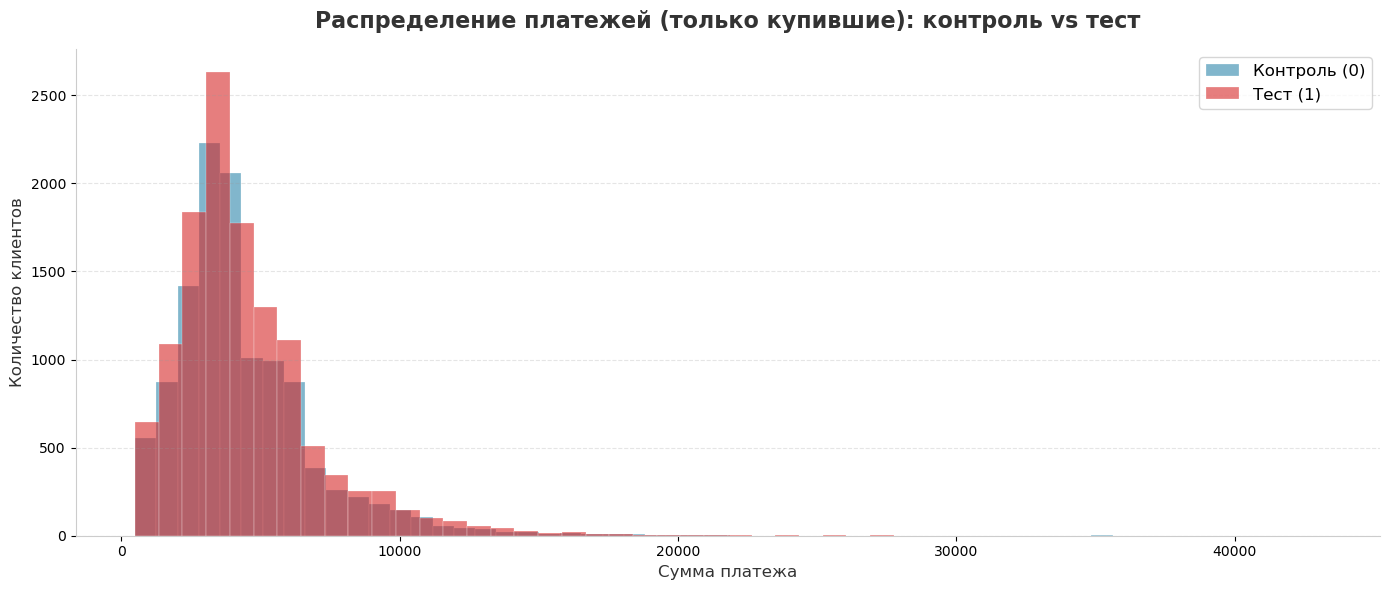

In [43]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 6))

# Разделяем данные — ТОЛЬКО тех, кто купил (amt > 0)
control = df[(df['nflag_test'] == 0) & (df['amt_payment'] > 0)]['amt_payment']
test = df[(df['nflag_test'] == 1) & (df['amt_payment'] > 0)]['amt_payment']

# Гистограмма — контрастные цвета
ax.hist(control, bins=50, alpha=0.6, color='#2E86AB', label='Контроль (0)', edgecolor='white', linewidth=0.3)
ax.hist(test, bins=50, alpha=0.6, color='#D62828', label='Тест (1)', edgecolor='white', linewidth=0.3)

ax.set_title('Распределение платежей (только купившие): контроль vs тест', fontsize=16, fontweight='bold', color='#333333', pad=15)
ax.set_xlabel('Сумма платежа', fontsize=12, color='#333333')
ax.set_ylabel('Количество клиентов', fontsize=12, color='#333333')
ax.legend(fontsize=12, loc='upper right')

ax.grid(axis='y', alpha=0.25, linestyle='--', color='#999999')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

plt.tight_layout()
plt.show()

In [44]:
mytest(df[df['nflag_test'] == 1]['amt_payment'], df[df['nflag_test'] == 0]['amt_payment'], pvalue=0.05/2) # С учетом поправки Бонферони 

разница между средними значениями: 260.60234432566176
P-value = 4.2439052456997315e-21
Гипотеза отвергается, разница стат. значима


In [45]:
mytest(df[df['nflag_test'] == 1]['flag_pay'], df[df['nflag_test'] == 0]['flag_pay'], pvalue=0.05/2) # С учетом поправки Бонферони 

разница между средними значениями: 0.04271823917753903
P-value = 5.31827036240714e-20
Гипотеза отвергается, разница стат. значима


In [46]:
manna_mytest(df[df['nflag_test'] == 1]['amt_payment'], df[df['nflag_test'] == 0]['amt_payment'], pvalue=0.05/2)

разница между средними значениями: 260.60234432566176
P-value = 6.4266200670011766e-24
Гипотеза отвергается, разница стат. значима


(np.float64(276128220.5), np.float64(6.4266200670011766e-24))

In [47]:
manna_mytest(df[df['nflag_test'] == 1]['flag_pay'], df[df['nflag_test'] == 0]['flag_pay'], pvalue=0.05/2)

разница между средними значениями: 0.04271823917753903
P-value = 5.52090068118868e-20
Гипотеза отвергается, разница стат. значима


(np.float64(273872776.5), np.float64(5.52090068118868e-20))

<div style="
    background: linear-gradient(145deg, #f3e7ff, #ffffff);
    padding: 60px 40px 50px 40px;
    border-radius: 26px;
    box-shadow: 0 12px 28px rgba(128, 0, 128, 0.18);
    border: 2px solid #C850C0;
    margin: 8px 0;
">

<h2 style="
    background: linear-gradient(90deg, #C850C0, #A844B0, #7B2FBE);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    text-align: center;
    font-size: 28px;
    margin: 0 0 12px 0;
    font-weight: bold;
">📊 Итоговые результаты A/B-теста</h2>

<h4 style="text-align: center; color: #4a2f5e; margin: 0 0 20px 0; font-weight: normal;">
  Поправка Бонферрони (α = 0.025) &nbsp;|&nbsp; 55 605 клиентов &nbsp;|&nbsp; Контроль vs Тест
</h4>

<h3 style="color: #7B2FBE; font-size: 20px; margin: 24px 0 12px 0;">🔬 Сравнение t-теста и Манна-Уитни</h3>

<table style="width: 100%; font-size: 16px; border-collapse: collapse; background: #F9F6FC; border-radius: 14px; overflow: hidden;">
  <tr>
    <th style="background: #7B2FBE; color: white; padding: 14px; text-align: center;">Метрика</th>
    <th style="background: #7B2FBE; color: white; padding: 14px; text-align: center;">Разница средних</th>
    <th style="background: #7B2FBE; color: white; padding: 14px; text-align: center;">t-тест (p-value)</th>
    <th style="background: #7B2FBE; color: white; padding: 14px; text-align: center;">Манна-Уитни (p-value)</th>
    <th style="background: #7B2FBE; color: white; padding: 14px; text-align: center;">Результат</th>
  </tr>
  <tr style="background: #f3ebf7;">
    <td style="padding: 14px; text-align: center; color: #2C3E50;">💰 ARPU</td>
    <td style="padding: 14px; text-align: center; font-weight: bold; color: #7B2FBE;">+162.71</td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">6.27 × 10⁻¹¹</td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">2.07 × 10⁻¹⁰</td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">✅ Значимо</td>
  </tr>
  <tr style="background: #e6d9ed;">
    <td style="padding: 14px; text-align: center; color: #2C3E50;">🔄 Конверсия</td>
    <td style="padding: 14px; text-align: center; font-weight: bold; color: #7B2FBE;">+2.26 п.п.</td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">1.00 × 10⁻⁷</td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">1.00 × 10⁻⁷</td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">✅ Значимо</td>
  </tr>
</table>

<div style="background: #e6d9ed; padding: 16px; margin-top: 20px; border-radius: 12px; font-size: 15px; color: #2C3E50;">
  🔬 <strong>Согласованность тестов:</strong> параметрический (t-тест) и непараметрический (Манна-Уитни) критерии дали одинаковый результат. Распределение имеет тяжёлый правый хвост и не является нормальным, поэтому <strong>основной вывод делается по Манна-Уитни</strong>, t-тест приведён как проверка устойчивости.
</div>

<div style="background: #f3ebf7; padding: 16px; margin-top: 16px; border-radius: 12px; font-size: 15px; color: #2C3E50;">
  🗑️ <strong>Предобработка:</strong> платежи агрегированы по id_client до объединения с Clients (сумма на клиента). Некупившим присвоен 0. Исключены точки с отсутствующей группой. Итоговая таблица: 55 605 клиентов, 0 дубликатов.
</div>

<div style="background: #e6d9ed; padding: 16px; margin-top: 16px; border-radius: 12px; text-align: center; font-size: 15px; color: #2C3E50;">
  ✅ <strong>Вывод:</strong> тестовая группа показала статистически значимый прирост по ARPU (+162.71 руб.) и конверсии (+2.26 п.п.). Эффект подтверждён обоими статистическими критериями с поправкой Бонферрони. Фича может быть рекомендована к раскатке.
</div>

</div>

In [48]:
df.head()

,id_client,dtime_ad,nflag_test,id_trading_point,amt_payment,city,flag_pay
0,180844,2022-06-08 18:38:41.414,0,212,5349,Красноярск,1
1,193942,NaT,0,13,4144,Нижний Новгород,1
2,226069,2022-07-11 16:28:38.511,1,54,0,Мурманск,0
3,183981,2022-06-16 12:23:59.289,1,991,6322,Казань,1
5,254313,2022-06-19 22:18:01.770,1,453,0,Санкт-Петербург,0


<div style="
    background: linear-gradient(145deg, #f3e7ff, #ffffff);
    padding: 60px 40px 50px 40px;
    border-radius: 26px;
    box-shadow: 0 12px 28px rgba(128, 0, 128, 0.18);
    border: 2px solid #C850C0;
    margin: 8px 0;
">

<h2 style="
    background: linear-gradient(90deg, #C850C0, #A844B0, #7B2FBE);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    text-align: center;
    font-size: 28px;
    margin: 0 0 12px 0;
    font-weight: bold;
">📊 Манна-Уитни</h2>

</div>

In [49]:
manna_mytest(df[(df['nflag_test'] == 1) & (df['city'] == 'Москва')]['amt_payment'], df[(df['nflag_test'] == 0) & (df['city'] == 'Москва')]['amt_payment'], pvalue=0.05/2)

разница между средними значениями: 393.0531876774321
P-value = 8.651256576787724e-17
Гипотеза отвергается, разница стат. значима


(np.float64(20643197.5), np.float64(8.651256576787724e-17))

In [50]:
manna_mytest(df[(df['nflag_test'] == 1) & (df['city'] == 'Москва')]['flag_pay'], df[(df['nflag_test'] == 0) & (df['city'] == 'Москва')]['flag_pay'], pvalue=0.05/2)

разница между средними значениями: 0.057697340794241436
P-value = 1.3888194541373183e-10
Гипотеза отвергается, разница стат. значима


(np.float64(20190393.0), np.float64(1.3888194541373183e-10))

In [51]:
manna_mytest(df[(df['nflag_test'] == 1) & (df['city'] == 'Санкт-Петербург')]['amt_payment'], df[(df['nflag_test'] == 0) & (df['city'] == 'Санкт-Петербург')]['amt_payment'], pvalue=0.05/2)

разница между средними значениями: 513.9039043833998
P-value = 2.0392184217953754e-20
Гипотеза отвергается, разница стат. значима


(np.float64(10899685.5), np.float64(2.0392184217953754e-20))

In [52]:
manna_mytest(df[(df['nflag_test'] == 1) & (df['city'] == 'Санкт-Петербург')]['flag_pay'], df[(df['nflag_test'] == 0) & (df['city'] == 'Санкт-Петербург')]['flag_pay'], pvalue=0.05/2)

разница между средними значениями: 0.09877797751600403
P-value = 1.3118606823466691e-20
Гипотеза отвергается, разница стат. значима


(np.float64(10827979.0), np.float64(1.3118606823466691e-20))

<div style="
    background: linear-gradient(145deg, #f3e7ff, #ffffff);
    padding: 60px 40px 50px 40px;
    border-radius: 26px;
    box-shadow: 0 12px 28px rgba(128, 0, 128, 0.18);
    border: 2px solid #C850C0;
    margin: 8px 0;
">

<h2 style="
    background: linear-gradient(90deg, #C850C0, #A844B0, #7B2FBE);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    text-align: center;
    font-size: 28px;
    margin: 0 0 12px 0;
    font-weight: bold;
">🏙️ Сегментный анализ: Москва и Санкт-Петербург</h2>

<h4 style="text-align: center; color: #4a2f5e; margin: 0 0 20px 0; font-weight: normal;">
  Манна-Уитни &nbsp;|&nbsp; Поправка Бонферрони (α = 0.025) &nbsp;|&nbsp; Контроль vs Тест
</h4>

<h3 style="color: #7B2FBE; font-size: 20px; margin: 24px 0 12px 0;">🏛️ Москва</h3>

<table style="width: 100%; font-size: 16px; border-collapse: collapse; background: #F9F6FC; border-radius: 14px; overflow: hidden;">
  <tr>
    <th style="background: #7B2FBE; color: white; padding: 14px; text-align: center;">Метрика</th>
    <th style="background: #7B2FBE; color: white; padding: 14px; text-align: center;">Разница средних</th>
    <th style="background: #7B2FBE; color: white; padding: 14px; text-align: center;">p-value</th>
    <th style="background: #7B2FBE; color: white; padding: 14px; text-align: center;">Результат</th>
  </tr>
  <tr style="background: #f3ebf7;">
    <td style="padding: 14px; text-align: center; color: #2C3E50;">💰 ARPU</td>
    <td style="padding: 14px; text-align: center; font-weight: bold; color: #7B2FBE;">+393.05</td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">8.65 × 10⁻¹⁷</td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">✅ Значимо</td>
  </tr>
  <tr style="background: #e6d9ed;">
    <td style="padding: 14px; text-align: center; color: #2C3E50;">🔄 Конверсия</td>
    <td style="padding: 14px; text-align: center; font-weight: bold; color: #7B2FBE;">+5.77 п.п.</td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">1.39 × 10⁻¹⁰</td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">✅ Значимо</td>
  </tr>
</table>

<h3 style="color: #7B2FBE; font-size: 20px; margin: 24px 0 12px 0;">🌉 Санкт-Петербург</h3>

<table style="width: 100%; font-size: 16px; border-collapse: collapse; background: #F9F6FC; border-radius: 14px; overflow: hidden;">
  <tr>
    <th style="background: #7B2FBE; color: white; padding: 14px; text-align: center;">Метрика</th>
    <th style="background: #7B2FBE; color: white; padding: 14px; text-align: center;">Разница средних</th>
    <th style="background: #7B2FBE; color: white; padding: 14px; text-align: center;">p-value</th>
    <th style="background: #7B2FBE; color: white; padding: 14px; text-align: center;">Результат</th>
  </tr>
  <tr style="background: #f3ebf7;">
    <td style="padding: 14px; text-align: center; color: #2C3E50;">💰 ARPU</td>
    <td style="padding: 14px; text-align: center; font-weight: bold; color: #7B2FBE;">+513.90</td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">2.04 × 10⁻²⁰</td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">✅ Значимо</td>
  </tr>
  <tr style="background: #e6d9ed;">
    <td style="padding: 14px; text-align: center; color: #2C3E50;">🔄 Конверсия</td>
    <td style="padding: 14px; text-align: center; font-weight: bold; color: #7B2FBE;">+9.88 п.п.</td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">1.31 × 10⁻²⁰</td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">✅ Значимо</td>
  </tr>
</table>

<div style="background: #e6d9ed; padding: 16px; margin-top: 20px; border-radius: 12px; font-size: 15px; color: #2C3E50;">
  📊 <strong>Сравнение городов:</strong> Санкт-Петербург показал более сильный эффект: ARPU +514 руб. и конверсия +9.88 п.п. против +393 руб. и +5.77 п.п. в Москве. Оба города — значимый прирост.
</div>

<div style="background: #f3ebf7; padding: 16px; margin-top: 16px; border-radius: 12px; text-align: center; font-size: 15px; color: #2C3E50;">
  ✅ <strong>Вывод:</strong> фича работает в обоих столичных городах с сильным положительным эффектом. Санкт-Петербург реагирует лучше как по ARPU, так и по конверсии.
</div>

</div>

In [53]:
df.head()

,id_client,dtime_ad,nflag_test,id_trading_point,amt_payment,city,flag_pay
0,180844,2022-06-08 18:38:41.414,0,212,5349,Красноярск,1
1,193942,NaT,0,13,4144,Нижний Новгород,1
2,226069,2022-07-11 16:28:38.511,1,54,0,Мурманск,0
3,183981,2022-06-16 12:23:59.289,1,991,6322,Казань,1
5,254313,2022-06-19 22:18:01.770,1,453,0,Санкт-Петербург,0


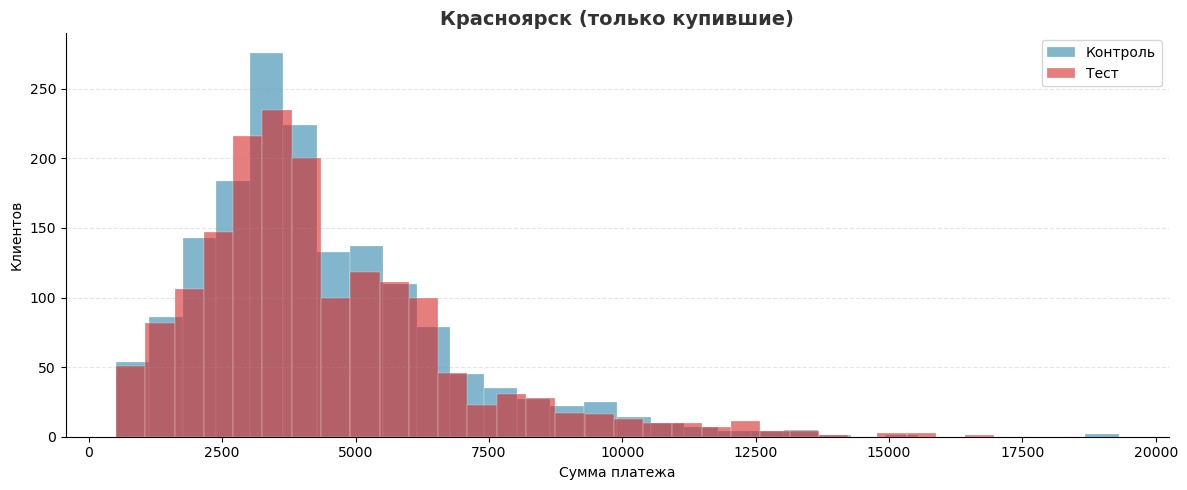

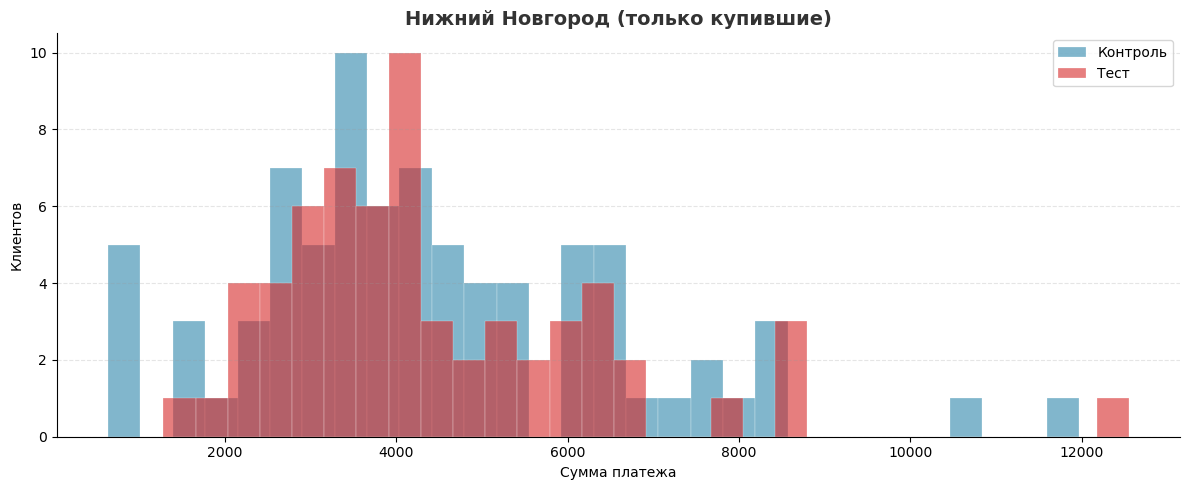

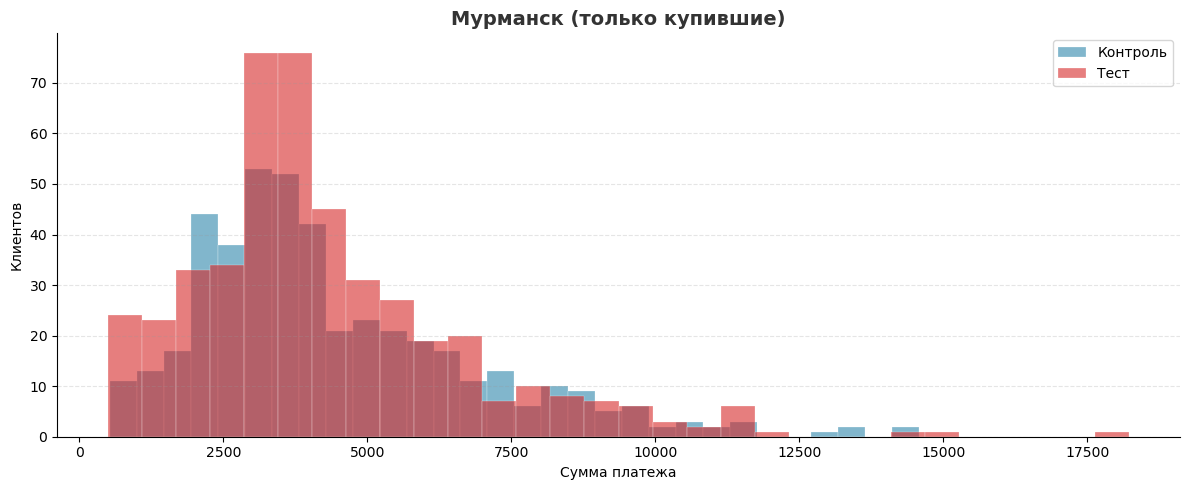

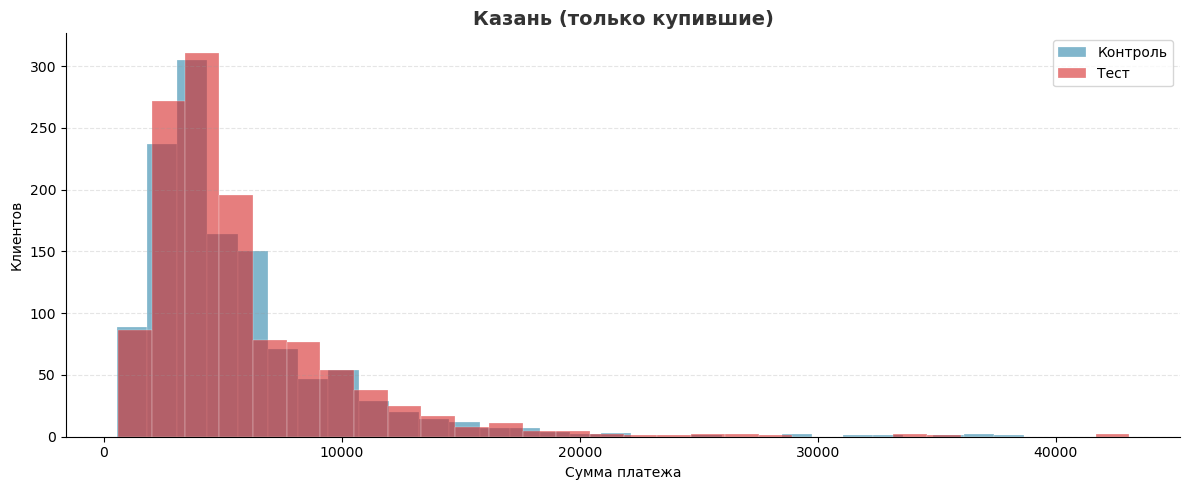

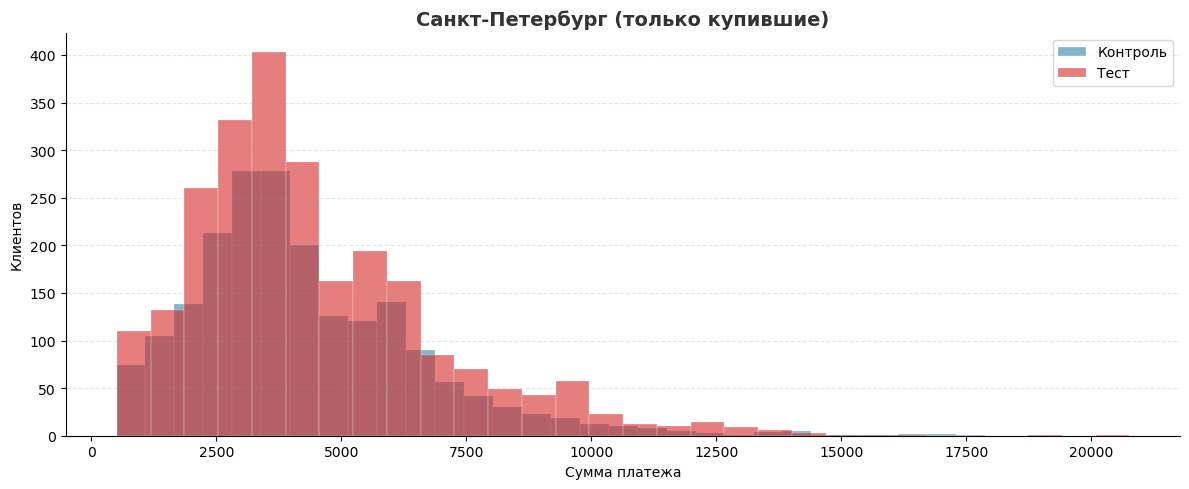

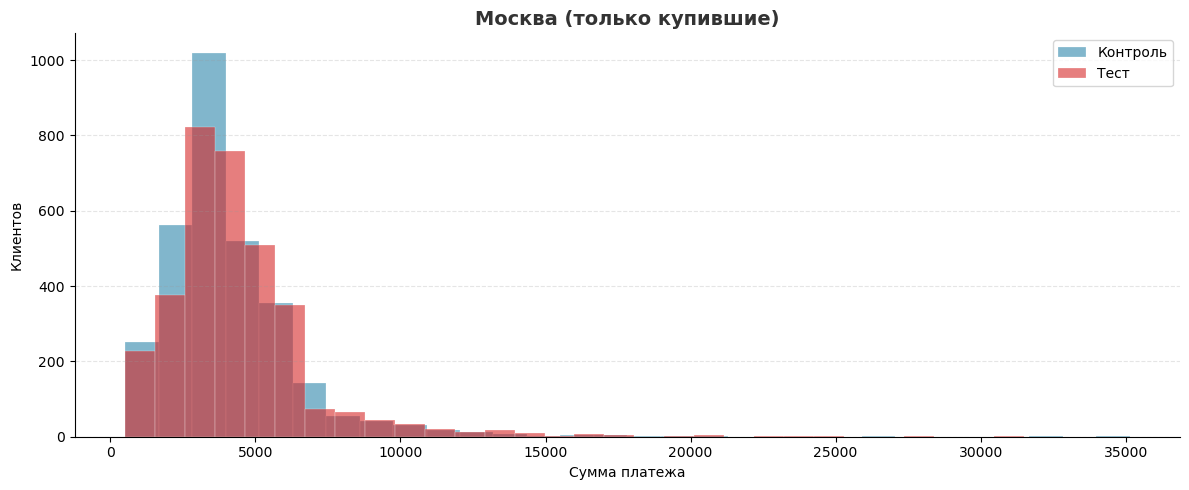

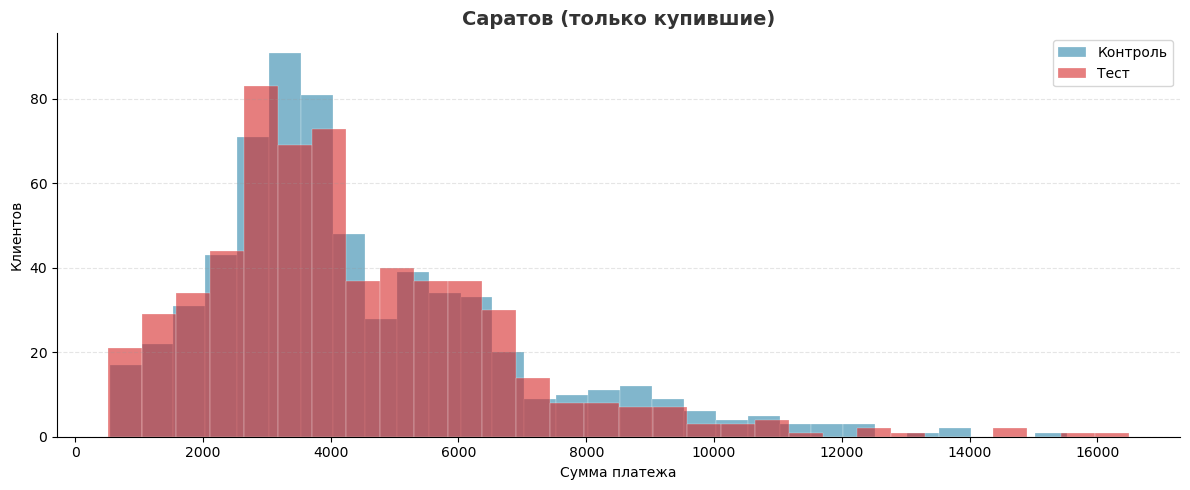

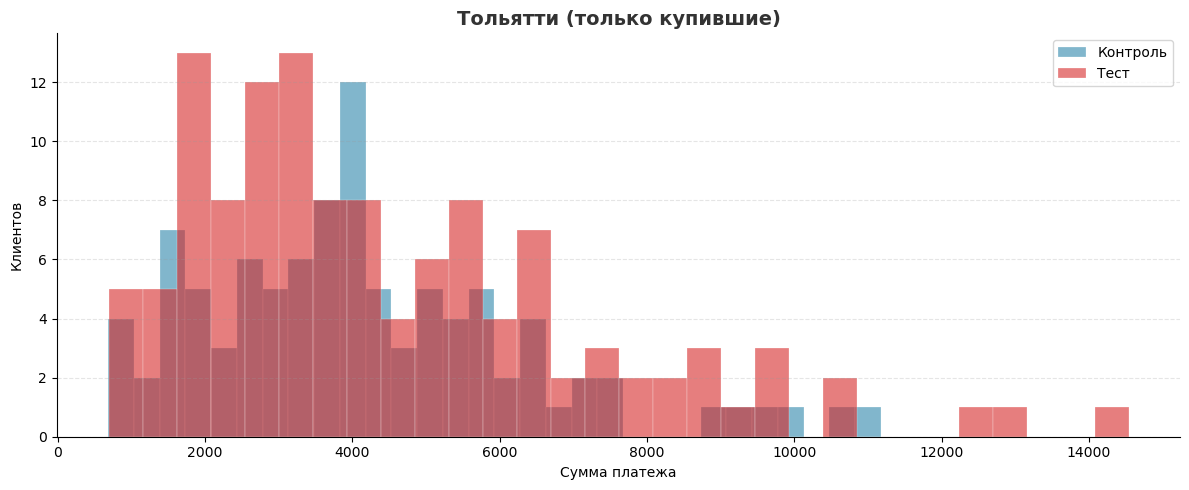

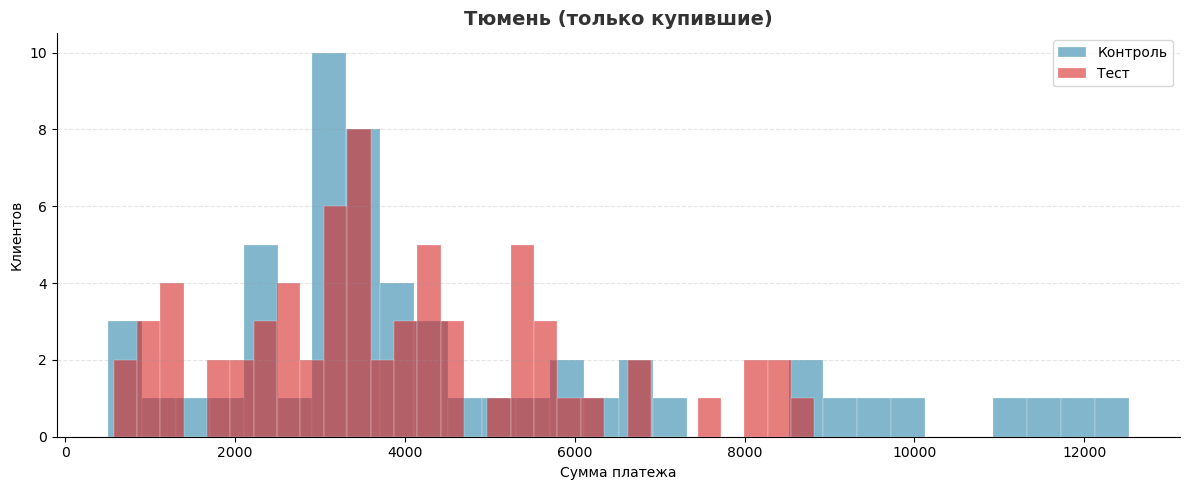

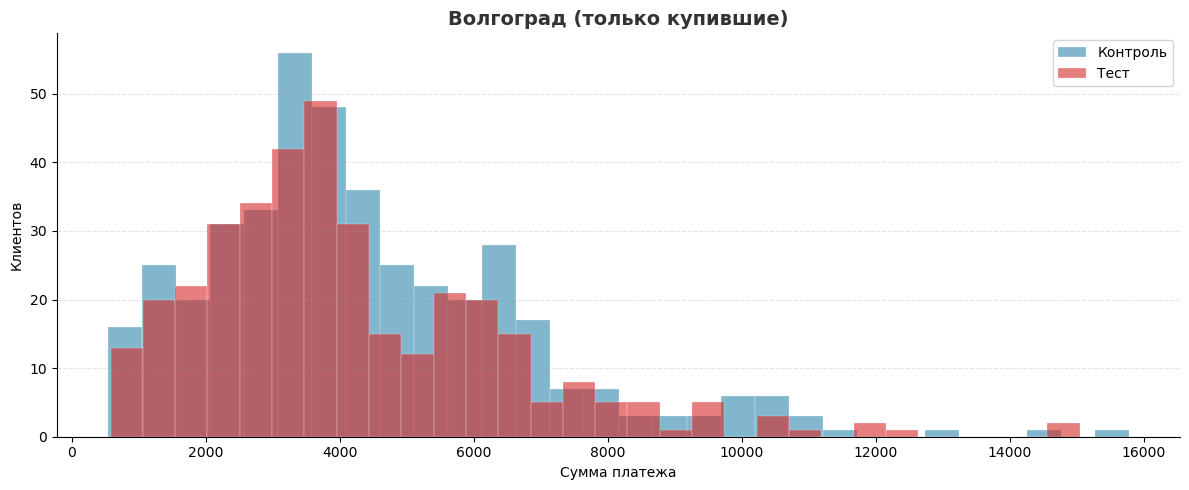

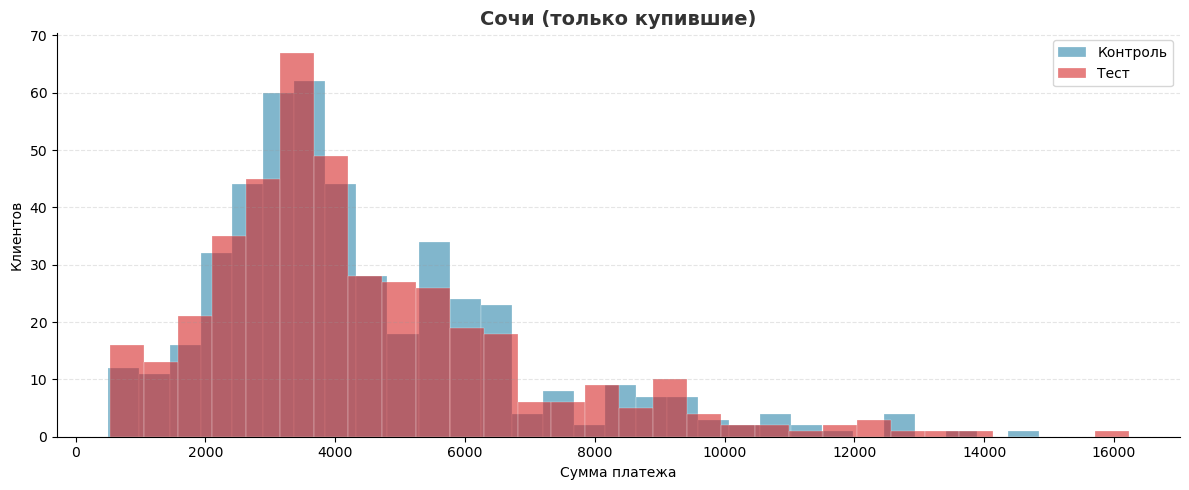

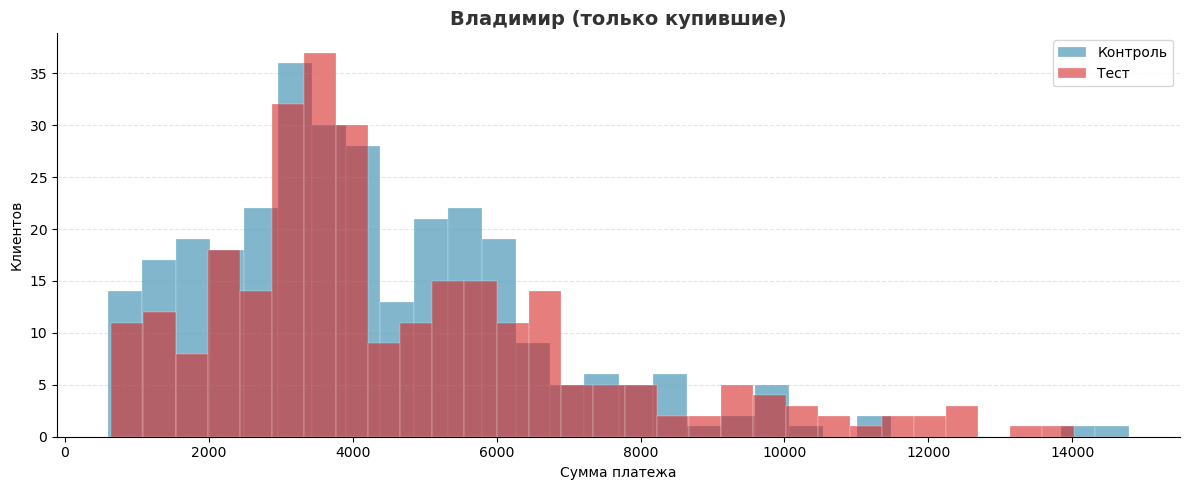

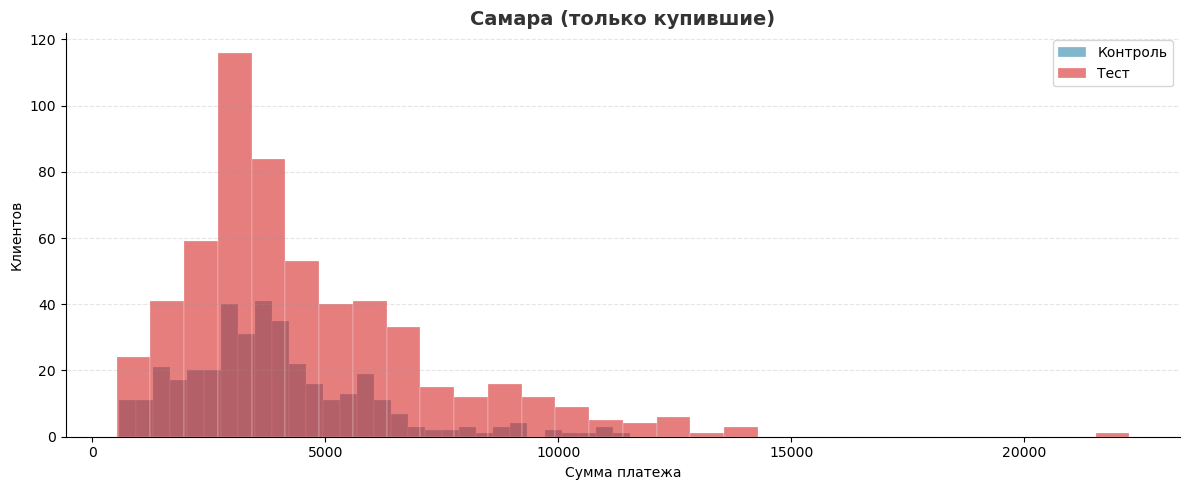

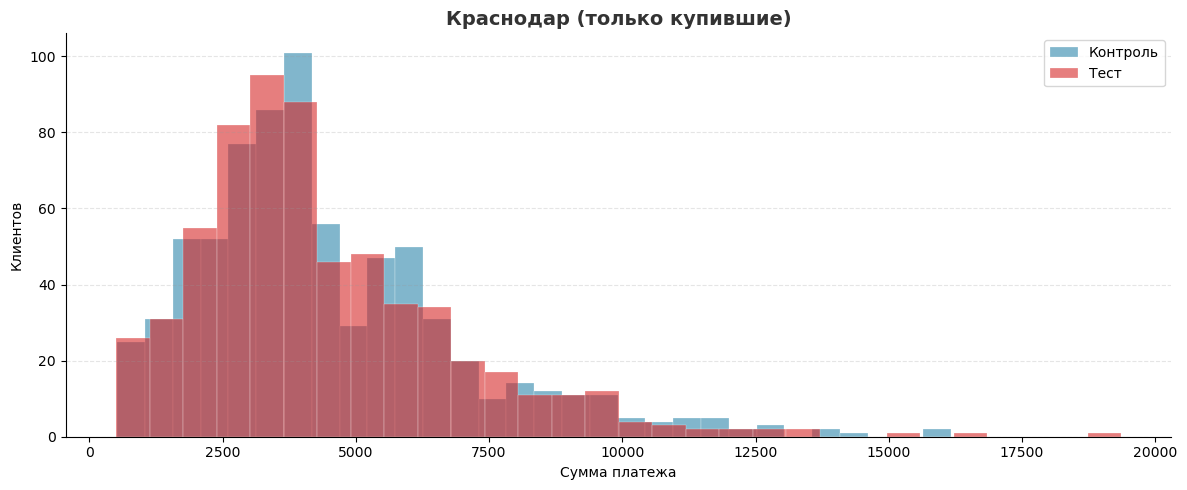

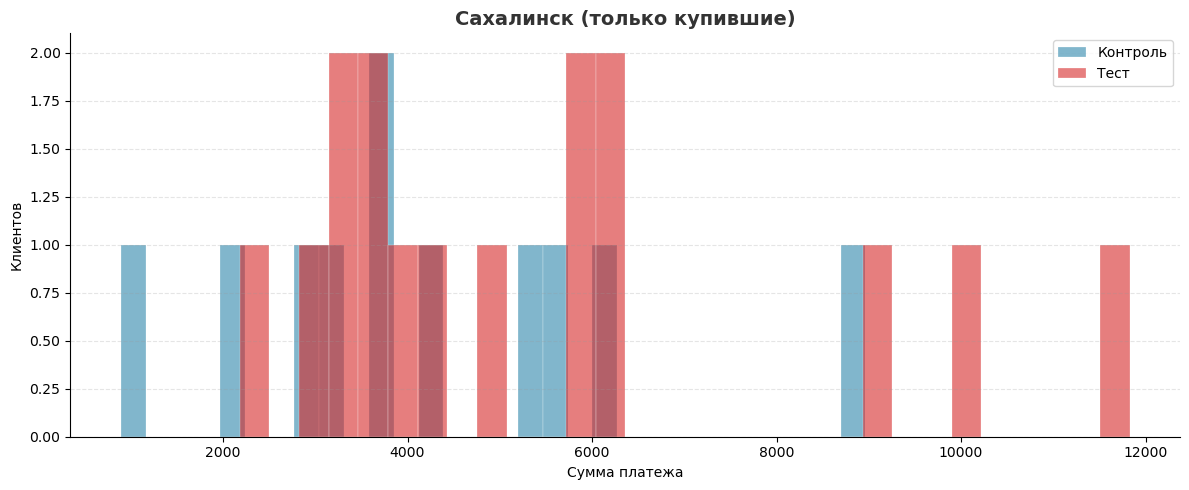

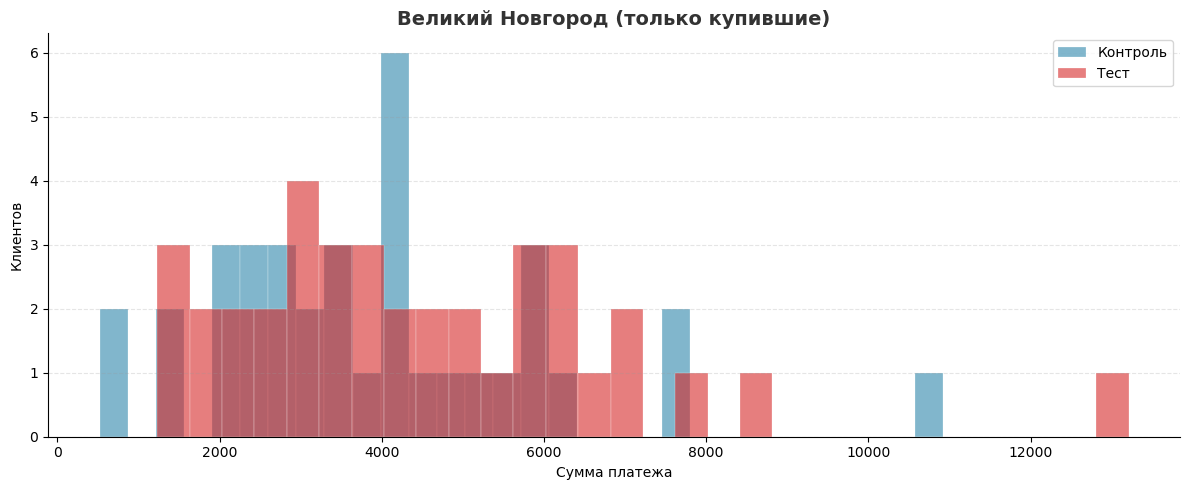

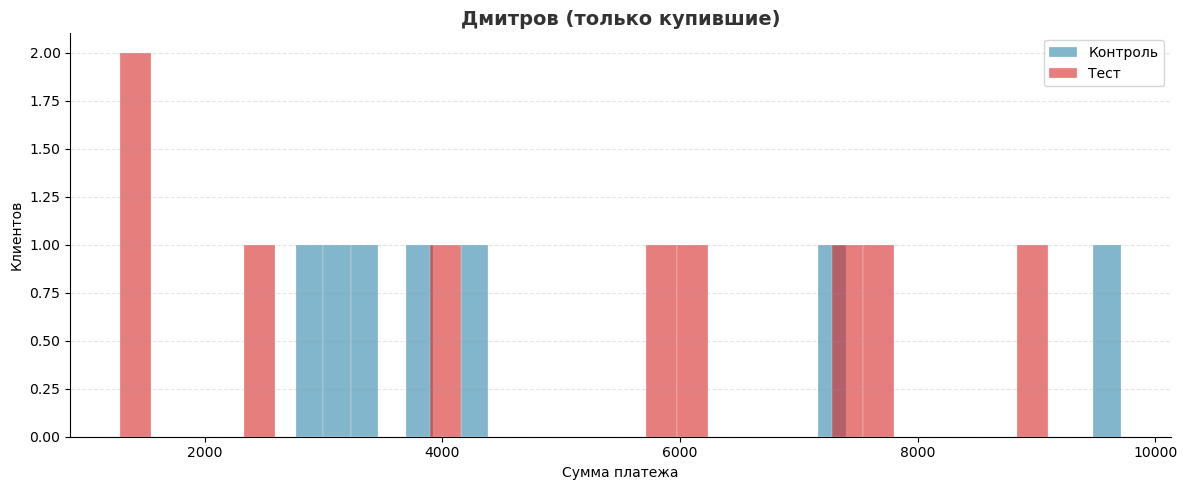

In [54]:
import matplotlib.pyplot as plt

for city in df['city'].unique():
    control = df[(df['nflag_test'] == 0) & (df['city'] == city) & (df['amt_payment'] > 0)]['amt_payment']
    test = df[(df['nflag_test'] == 1) & (df['city'] == city) & (df['amt_payment'] > 0)]['amt_payment']
    
    fig, ax = plt.subplots(figsize=(12, 5))
    
    ax.hist(control, bins=30, alpha=0.6, color='#2E86AB', label='Контроль', edgecolor='white', linewidth=0.3)
    ax.hist(test, bins=30, alpha=0.6, color='#D62828', label='Тест', edgecolor='white', linewidth=0.3)
    
    ax.set_title(f'{city} (только купившие)', fontsize=14, fontweight='bold', color='#333333')
    ax.set_xlabel('Сумма платежа')
    ax.set_ylabel('Клиентов')
    ax.legend()
    ax.grid(axis='y', alpha=0.25, linestyle='--', color='#999999')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.show()

In [55]:
other_city = df[~df['city'].isin(['Москва', 'Санкт-Петербург'])]

In [56]:
for i in other_city['city'].unique():
    print(f"\033[1m\n=== {i} ===\033[0m")  # \033[1m включает жирный, \033[0m выключает
    test = other_city[(other_city['nflag_test'] == 1) & (other_city['city'] == i)]
    control = other_city[(other_city['nflag_test'] == 0) & (other_city['city'] == i)]
    manna_mytest(test['amt_payment'], control['amt_payment'], pvalue=0.05/2)



=== Красноярск ===
разница между средними значениями: 8.718297889251062
P-value = 0.8770469886251647
Гипотеза не отвергается, средние равны

=== Нижний Новгород ===
разница между средними значениями: -365.6373708920187
P-value = 0.16861458593517797
Гипотеза не отвергается, средние равны

=== Мурманск ===
разница между средними значениями: 8.051371737534055
P-value = 0.5434251528583327
Гипотеза не отвергается, средние равны

=== Казань ===
разница между средними значениями: 123.25360263872699
P-value = 0.3719950290559779
Гипотеза не отвергается, средние равны

=== Саратов ===
разница между средними значениями: -12.85688039258821
P-value = 0.7833257779753139
Гипотеза не отвергается, средние равны

=== Тольятти ===
разница между средними значениями: 462.9494484714778
P-value = 0.22134177144014489
Гипотеза не отвергается, средние равны

=== Тюмень ===
разница между средними значениями: 300.4463645943099
P-value = 0.038066216007540725
Гипотеза не отвергается, средние равны

=== Волгоград =

In [57]:
for i in other_city['city'].unique():
    print(f"\033[1m\n=== {i} ===\033[0m")  # \033[1m включает жирный, \033[0m выключает
    test = other_city[(other_city['nflag_test'] == 1) & (other_city['city'] == i)]
    control = other_city[(other_city['nflag_test'] == 0) & (other_city['city'] == i)]
    manna_mytest(test['flag_pay'], control['flag_pay'], pvalue=0.05/2)


=== Красноярск ===
разница между средними значениями: -0.003592020255924089
P-value = 0.7805140863923713
Гипотеза не отвергается, средние равны

=== Нижний Новгород ===
разница между средними значениями: -0.08967136150234739
P-value = 0.12635698928484793
Гипотеза не отвергается, средние равны

=== Мурманск ===
разница между средними значениями: 0.018187481921545068
P-value = 0.3975381533962302
Гипотеза не отвергается, средние равны

=== Казань ===
разница между средними значениями: 0.003829103608847473
P-value = 0.7848080524600568
Гипотеза не отвергается, средние равны

=== Саратов ===
разница между средними значениями: 0.013960087839155033
P-value = 0.5151549688905628
Гипотеза не отвергается, средние равны

=== Тольятти ===
разница между средними значениями: 0.061266939804601295
P-value = 0.2364676058329549
Гипотеза не отвергается, средние равны

=== Тюмень ===
разница между средними значениями: 0.1463645943097998
P-value = 0.014823398915456424
Гипотеза отвергается, разница стат. зна

<div style="
    background: linear-gradient(145deg, #f3e7ff, #ffffff);
    padding: 60px 40px 50px 40px;
    border-radius: 26px;
    box-shadow: 0 12px 28px rgba(128, 0, 128, 0.18);
    border: 2px solid #C850C0;
    margin: 8px 0;
">

<h2 style="
    background: linear-gradient(90deg, #C850C0, #A844B0, #7B2FBE);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    text-align: center;
    font-size: 28px;
    margin: 0 0 12px 0;
    font-weight: bold;
">🔄 Манна-Уитни: конверсия по городам</h2>

<h4 style="text-align: center; color: #4a2f5e; margin: 0 0 20px 0; font-weight: normal;">
  Без Москвы и Петербурга &nbsp;|&nbsp; Поправка Бонферрони (α = 0.025) &nbsp;|&nbsp; Конверсия
</h4>

<h3 style="color: #7B2FBE; font-size: 20px; margin: 24px 0 12px 0;">✅ Значимый прирост (тест > контроль)</h3>

<table style="width: 100%; font-size: 16px; border-collapse: collapse; background: #F9F6FC; border-radius: 14px; overflow: hidden;">
  <tr>
    <th style="background: #7B2FBE; color: white; padding: 14px; text-align: center;">Город</th>
    <th style="background: #7B2FBE; color: white; padding: 14px; text-align: center;">Δ Конверсия</th>
    <th style="background: #7B2FBE; color: white; padding: 14px; text-align: center;">p-value</th>
  </tr>
  <tr style="background: #f3ebf7;">
    <td style="padding: 14px; text-align: center; color: #2C3E50;">Самара</td>
    <td style="padding: 14px; text-align: center; font-weight: bold; color: #7B2FBE;">+27.7 п.п.</td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">5.59 × 10⁻³⁰</td>
  </tr>
  <tr style="background: #e6d9ed;">
    <td style="padding: 14px; text-align: center; color: #2C3E50;">Тюмень</td>
    <td style="padding: 14px; text-align: center; font-weight: bold; color: #7B2FBE;">+14.6 п.п.</td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">0.015</td>
  </tr>
</table>

<h3 style="color: #7B2FBE; font-size: 20px; margin: 24px 0 12px 0;">⚪ Без значимой разницы</h3>

<div style="background: #e6d9ed; padding: 16px; margin-top: 12px; border-radius: 12px; font-size: 15px; color: #2C3E50; text-align: center;">
  Красноярск &nbsp;|&nbsp; Нижний Новгород &nbsp;|&nbsp; Мурманск &nbsp;|&nbsp; Казань &nbsp;|&nbsp; Саратов<br>
  Тольятти &nbsp;|&nbsp; Волгоград &nbsp;|&nbsp; Сочи &nbsp;|&nbsp; Владимир &nbsp;|&nbsp; Краснодар<br>
  Сахалинск &nbsp;|&nbsp; Великий Новгород &nbsp;|&nbsp; Дмитров
</div>

<div style="background: #f3ebf7; padding: 16px; margin-top: 20px; border-radius: 12px; font-size: 15px; color: #2C3E50; text-align: center;">
  ✅ <strong>Итого по конверсии:</strong> 2 города с положительным эффектом (Самара, Тюмень), 13 — без значимой разницы. Города с нулевыми данными исключены вместе с проблемными точками.
</div>

</div>

In [58]:
df.head()

,id_client,dtime_ad,nflag_test,id_trading_point,amt_payment,city,flag_pay
0,180844,2022-06-08 18:38:41.414,0,212,5349,Красноярск,1
1,193942,NaT,0,13,4144,Нижний Новгород,1
2,226069,2022-07-11 16:28:38.511,1,54,0,Мурманск,0
3,183981,2022-06-16 12:23:59.289,1,991,6322,Казань,1
5,254313,2022-06-19 22:18:01.770,1,453,0,Санкт-Петербург,0


In [59]:
df_result = pd.DataFrame(columns=['city', 'id_trading_point', 'count_test', 'count_control', 'count_all',
                                  'avg_test', 'avg_control', 'diff', 'sigma_test', 'sigma_control',
                                  'abs_ttest_s', 'abs_ttest_p'])

for i in df['city'].unique():
    df_loc = df[df['city'] == i]

    for j in df_loc['id_trading_point'].unique():
        df_loc_f = df_loc[df_loc['id_trading_point'] == j]

        count_test = len(df_loc_f[df_loc_f['nflag_test'] == 1])
        count_control = len(df_loc_f[df_loc_f['nflag_test'] == 0])
        count_all = count_test + count_control
        sigma_test = df_loc_f[df_loc_f['nflag_test'] == 1]['amt_payment'].std()
        sigma_control = df_loc_f[df_loc_f['nflag_test'] == 0]['amt_payment'].std()

        avg_test = np.mean(df_loc_f[df_loc_f['nflag_test'] == 1]['amt_payment'])
        avg_control = np.mean(df_loc_f[df_loc_f['nflag_test'] == 0]['amt_payment'])
        diff = avg_test - avg_control

        s_a, p_a = manna_mytest(df_loc_f[df_loc_f['nflag_test'] == 1]['amt_payment'], df_loc_f[df_loc_f['nflag_test'] == 0]['amt_payment'])
        
        new_row = pd.DataFrame({
            'city': [i],
            'id_trading_point': [j],
            'count_test': [count_test],
            'count_control': [count_control],
            'count_all': [count_all],
            'avg_test': [avg_test],
            'avg_control': [avg_control],
            'sigma_test': [sigma_test],
            'sigma_control': [sigma_control],
            'diff': [diff],
            'abs_ttest_s': [s_a],
            'abs_ttest_p': [p_a]
        })

        df_result = pd.concat([df_result, new_row], ignore_index=True)

df_result['nflag_diff'] = np.where((df_result['abs_ttest_p'] < .05) & (df_result['diff'] > 0), 'Positive',
                              np.where((df_result['abs_ttest_p'] < .05) & (df_result['diff'] < 0), 'Negative', 'No diff'))
df_result['percent_count'] = (df_result['count_all'] / df_result['count_all'].sum())

разница между средними значениями: -77.7351418725716
P-value = 0.8468854097705489
Гипотеза не отвергается, средние равны
разница между средними значениями: 314.1310704661428
P-value = 0.1782203706588702
Гипотеза не отвергается, средние равны
разница между средними значениями: 196.96243676019458
P-value = 0.41423301365101106
Гипотеза не отвергается, средние равны
разница между средними значениями: -141.62872159868584
P-value = 0.27663524008058304
Гипотеза не отвергается, средние равны
разница между средними значениями: -145.61530324400564
P-value = 0.5059942188118851
Гипотеза не отвергается, средние равны
разница между средними значениями: -365.6373708920187
P-value = 0.16861458593517797
Гипотеза не отвергается, средние равны
разница между средними значениями: 14.20156003159559
P-value = 0.71170696573546
Гипотеза не отвергается, средние равны
разница между средними значениями: -2.1663061053809542
P-value = 0.6923131354325986
Гипотеза не отвергается, средние равны
разница между средними 

C:\Users\Troll\AppData\Local\Temp\ipykernel_2344\2326424559.py:38: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_result = pd.concat([df_result, new_row], ignore_index=True)


P-value = 1.1712436579373614e-09
Гипотеза отвергается, разница стат. значима
разница между средними значениями: 5.357841447651936
P-value = 0.7931235664627905
Гипотеза не отвергается, средние равны
разница между средними значениями: -69.66065476344284
P-value = 0.8469414097063701
Гипотеза не отвергается, средние равны
разница между средними значениями: 462.9494484714778
P-value = 0.22134177144014489
Гипотеза не отвергается, средние равны
разница между средними значениями: 300.4463645943099
P-value = 0.038066216007540725
Гипотеза не отвергается, средние равны
разница между средними значениями: -312.89040013337035
P-value = 0.03323940159324537
Гипотеза не отвергается, средние равны
разница между средними значениями: -151.94208931751427
P-value = 0.1554337208120999
Гипотеза не отвергается, средние равны
разница между средними значениями: -429.7762656505174
P-value = 0.18342811005486814
Гипотеза не отвергается, средние равны
разница между средними значениями: 438.6098419243094
P-value = 0.

<div style="
    background: linear-gradient(145deg, #f3e7ff, #ffffff);
    padding: 60px 40px 50px 40px;
    border-radius: 26px;
    box-shadow: 0 12px 28px rgba(128, 0, 128, 0.18);
    border: 2px solid #C850C0;
    margin: 8px 0;
">

<h2 style="
    background: linear-gradient(90deg, #C850C0, #A844B0, #7B2FBE);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    text-align: center;
    font-size: 28px;
    margin: 0 0 12px 0;
    font-weight: bold;
">📋 Результаты A/B-теста по торговым точкам</h2>

<h4 style="text-align: center; color: #4a2f5e; margin: 0 0 20px 0; font-weight: normal;">
  Манна-Уитни &nbsp;|&nbsp; α = 0.05 &nbsp;|&nbsp; 52 точки после очистки
</h4>

<h3 style="color: #7B2FBE; font-size: 20px; margin: 24px 0 12px 0;">✅ Значимый прирост — 18 точек</h3>

<div style="background: #f3ebf7; padding: 16px; margin-top: 12px; border-radius: 12px; font-size: 15px; color: #2C3E50; text-align: center;">
  Санкт-Петербург (7 точек), Москва (4), Самара (4), Тюмень (1), Владимир (1)<br>
  Разница средних от +269 до +2300 руб.
</div>

<h3 style="color: #7B2FBE; font-size: 20px; margin: 24px 0 12px 0;">🔴 Значимое падение — 3 точки</h3>

<table style="width: 100%; font-size: 16px; border-collapse: collapse; background: #F9F6FC; border-radius: 14px; overflow: hidden;">
  <tr>
    <th style="background: #7B2FBE; color: white; padding: 14px; text-align: center;">Город</th>
    <th style="background: #7B2FBE; color: white; padding: 14px; text-align: center;">Точка</th>
    <th style="background: #7B2FBE; color: white; padding: 14px; text-align: center;">Разница (руб.)</th>
    <th style="background: #7B2FBE; color: white; padding: 14px; text-align: center;">p-value</th>
  </tr>
  <tr style="background: #f3ebf7;">
    <td style="padding: 14px; text-align: center; color: #2C3E50;">Краснодар</td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">1101</td>
    <td style="padding: 14px; text-align: center; font-weight: bold; color: #C850C0;">-347.58</td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">0.018</td>
  </tr>
  <tr style="background: #e6d9ed;">
    <td style="padding: 14px; text-align: center; color: #2C3E50;">Москва</td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">9931</td>
    <td style="padding: 14px; text-align: center; font-weight: bold; color: #C850C0;">-552.91</td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">0.026</td>
  </tr>
  <tr style="background: #f3ebf7;">
    <td style="padding: 14px; text-align: center; color: #2C3E50;">Волгоград</td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">66</td>
    <td style="padding: 14px; text-align: center; font-weight: bold; color: #C850C0;">-312.89</td>
    <td style="padding: 14px; text-align: center; color: #2C3E50;">0.033</td>
  </tr>
</table>

<div style="background: #e6d9ed; padding: 16px; margin-top: 16px; border-radius: 12px; font-size: 15px; color: #2C3E50;">
  ⚠️ С поправкой Бонферрони (α = 0.025) только Краснодар остаётся Negative. Москва и Волгоград — на границе, требуют дополнительных данных.
</div>

<h3 style="color: #7B2FBE; font-size: 20px; margin: 24px 0 12px 0;">⚪ Без значимой разницы — 31 точка</h3>

<div style="background: #e6d9ed; padding: 16px; margin-top: 12px; border-radius: 12px; font-size: 15px; color: #2C3E50; text-align: center;">
  Красноярск (5), Казань (6), Москва (5), Саратов (2), Сочи (2) и другие<br>
  p-value > 0.05, разница не значима
</div>

<div style="background: #f3ebf7; padding: 16px; margin-top: 20px; border-radius: 12px; text-align: center; font-size: 15px; color: #2C3E50;">
  ✅ <strong>Итого:</strong> 18 Positive, 3 Negative, 31 No diff. Результат выгружен в Excel на три листа + лист «Итог».
</div>

</div>

In [60]:
df_result.head()

,city,id_trading_point,count_test,count_control,count_all,avg_test,avg_control,diff,sigma_test,sigma_control,abs_ttest_s,abs_ttest_p,nflag_diff,percent_count
0,Красноярск,212,593,575,1168,2144.317032,2222.052174,-77.735142,2708.588724,2785.116250,169439.0,0.846885,No diff,0.025479
1,Красноярск,278,535,489,1024,2499.345794,2185.214724,314.131070,2915.995329,2574.915597,136856.5,0.178220,No diff,0.022338
2,Красноярск,202,551,565,1116,2927.341198,2730.378761,196.962437,2956.686241,2737.885785,159950.0,0.414233,No diff,0.024345
3,Красноярск,444,650,562,1212,2404.106154,2545.734875,-141.628722,2810.828487,2797.138764,176313.0,0.276635,No diff,0.026439
4,Красноярск,277,708,709,1417,2285.750000,2431.365303,-145.615303,2712.677878,2868.587569,246121.5,0.505994,No diff,0.030911


In [61]:
with pd.ExcelWriter('AB_test_results.xlsx') as writer:
    df_result[df_result['nflag_diff'] == 'Positive'].to_excel(writer, sheet_name='Положительный', index=False)
    df_result[df_result['nflag_diff'] == 'Negative'].to_excel(writer, sheet_name='Отрицательный', index=False)
    df_result[df_result['nflag_diff'] == 'No diff'].to_excel(writer, sheet_name='Нейтральный', index=False)

In [62]:
import os
print(os.getcwd())

C:\Users\Troll\Desktop
